<a href="https://colab.research.google.com/github/Shayantan1012/DeepLearning-Projects/blob/main/PV_Forcasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd

dataset=pd.read_csv('/content/drive/MyDrive/XAI /Other data/PVGen-1.csv')
dataset=pd.DataFrame(dataset)
print(dataset.head())

               Time  Energy delta[Wh]  GHI  temp  pressure  humidity  \
0  01-01-2017 00:00                 0  0.0   1.6      1021       100   
1  01-01-2017 00:15                 0  0.0   1.6      1021       100   
2  01-01-2017 00:30                 0  0.0   1.6      1021       100   
3  01-01-2017 00:45                 0  0.0   1.6      1021       100   
4  01-01-2017 01:00                 0  0.0   1.7      1020       100   

   wind_speed  rain_1h  snow_1h  clouds_all  isSun  sunlightTime  dayLength  \
0         4.9      0.0      0.0         100      0             0        450   
1         4.9      0.0      0.0         100      0             0        450   
2         4.9      0.0      0.0         100      0             0        450   
3         4.9      0.0      0.0         100      0             0        450   
4         5.2      0.0      0.0         100      0             0        450   

   SunlightTime/daylength  weather_type  hour  month  
0                     0.0            

In [3]:
print(dataset.isna().sum())
print(dataset.columns)
print(len(dataset.columns))

Time                      0
Energy delta[Wh]          0
GHI                       0
temp                      0
pressure                  0
humidity                  0
wind_speed                0
rain_1h                   0
snow_1h                   0
clouds_all                0
isSun                     0
sunlightTime              0
dayLength                 0
SunlightTime/daylength    0
weather_type              0
hour                      0
month                     0
dtype: int64
Index(['Time', 'Energy delta[Wh]', 'GHI', 'temp', 'pressure', 'humidity',
       'wind_speed', 'rain_1h', 'snow_1h', 'clouds_all', 'isSun',
       'sunlightTime', 'dayLength', 'SunlightTime/daylength', 'weather_type',
       'hour', 'month'],
      dtype='object')
17


In [4]:
print(dataset.tail())

                    Time  Energy delta[Wh]   GHI  temp  pressure  humidity  \
196771  31-08-2022 16:45               118  23.7  18.6      1023        57   
196772  31-08-2022 17:00                82  15.6  18.5      1023        61   
196773  31-08-2022 17:15                51   8.0  18.5      1023        61   
196774  31-08-2022 17:30                24   2.1  18.5      1023        61   
196775  31-08-2022 17:45                 0   0.0  18.5      1023        61   

        wind_speed  rain_1h  snow_1h  clouds_all  isSun  sunlightTime  \
196771         3.8      0.0      0.0          52      1           780   
196772         4.2      0.0      0.0          60      1           795   
196773         4.2      0.0      0.0          60      1           810   
196774         4.2      0.0      0.0          60      1           825   
196775         4.2      0.0      0.0          60      0             0   

        dayLength  SunlightTime/daylength  weather_type  hour  month  
196771        825    

In [5]:
print(dataset.columns)
dataset['Time']

Index(['Time', 'Energy delta[Wh]', 'GHI', 'temp', 'pressure', 'humidity',
       'wind_speed', 'rain_1h', 'snow_1h', 'clouds_all', 'isSun',
       'sunlightTime', 'dayLength', 'SunlightTime/daylength', 'weather_type',
       'hour', 'month'],
      dtype='object')


,Time
0,01-01-2017 00:00
1,01-01-2017 00:15
2,01-01-2017 00:30
3,01-01-2017 00:45
4,01-01-2017 01:00
...,...
196771,31-08-2022 16:45
196772,31-08-2022 17:00
196773,31-08-2022 17:15
196774,31-08-2022 17:30


<ipython-input-6-0ff76377ba85>:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_data['Energy delta[MWh]']=filtered_data['Energy delta[Wh]']*1e-6


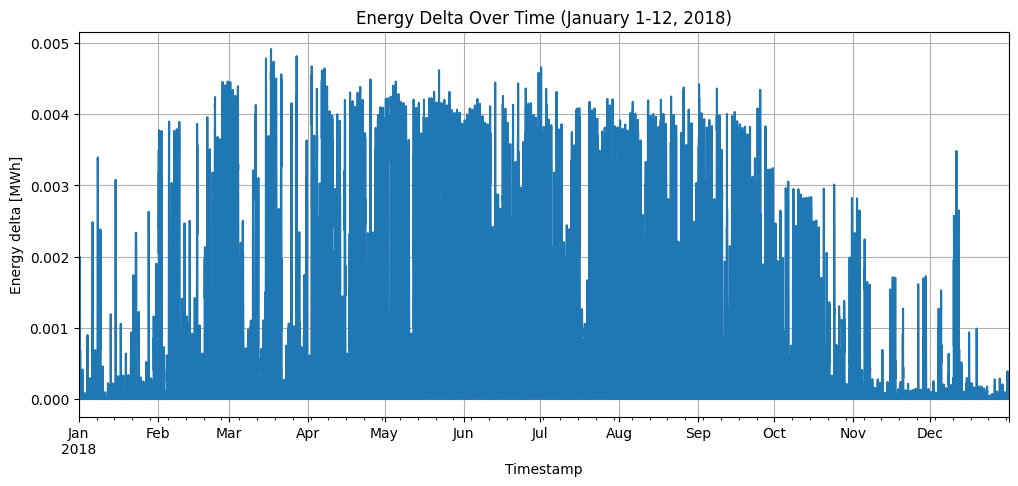

In [6]:
import matplotlib.pyplot as plt
start_time='2019-01-01'
end_time='2022-12-31'
dataset['Time'] = pd.to_datetime(dataset['Time'], format='%d-%m-%Y %H:%M')  # Adjust format to match your data
dataset.set_index('Time', inplace=True)
dataset = dataset[~((dataset.index >= start_time) & (dataset.index <= end_time))]
filtered_data = dataset['2018-01-01':'2018-12-31']  # Use YYYY-MM-DD format for slicing
filtered_data['Energy delta[MWh]']=filtered_data['Energy delta[Wh]']*1e-6

filtered_data['Energy delta[MWh]'].plot(figsize=(12, 5), title="Energy Delta Over Time (January 1-12, 2018)")
plt.xlabel("Timestamp")
plt.ylabel("Energy delta [MWh]")
plt.grid(True)
plt.show()



In [7]:
dataset.columns

Index(['Energy delta[Wh]', 'GHI', 'temp', 'pressure', 'humidity', 'wind_speed',
       'rain_1h', 'snow_1h', 'clouds_all', 'isSun', 'sunlightTime',
       'dayLength', 'SunlightTime/daylength', 'weather_type', 'hour', 'month'],
      dtype='object')

In [8]:
Y=filtered_data['Energy delta[MWh]']
X=filtered_data.drop(columns=['Energy delta[MWh]','Energy delta[Wh]'],axis=1)


print("X Head->",X.head)
print("X Tail->",X.tail)


X Head-> <bound method NDFrame.head of                      GHI  temp  pressure  humidity  wind_speed  rain_1h  \
Time                                                                      
2018-01-01 00:00:00  0.0   9.5       997        88         5.8      0.0   
2018-01-01 00:15:00  0.0   9.5       997        88         5.8      0.0   
2018-01-01 00:30:00  0.0   9.5       997        88         5.8      0.0   
2018-01-01 00:45:00  0.0   9.5       997        88         5.8      0.0   
2018-01-01 01:00:00  0.0   9.4       996        87         5.8      0.0   
...                  ...   ...       ...       ...         ...      ...   
2018-12-31 22:45:00  0.0   5.4      1024        98         5.4      0.0   
2018-12-31 23:00:00  0.0   5.8      1024        97         5.8      0.0   
2018-12-31 23:15:00  0.0   5.8      1024        97         5.8      0.0   
2018-12-31 23:30:00  0.0   5.8      1024        97         5.8      0.0   
2018-12-31 23:45:00  0.0   5.8      1024        97         5.

In [9]:
print(dataset.index)
print(type(dataset.index))

DatetimeIndex(['2017-01-01 00:00:00', '2017-01-01 00:15:00',
               '2017-01-01 00:30:00', '2017-01-01 00:45:00',
               '2017-01-01 01:00:00', '2017-01-01 01:15:00',
               '2017-01-01 01:30:00', '2017-01-01 01:45:00',
               '2017-01-01 02:00:00', '2017-01-01 02:15:00',
               ...
               '2018-12-31 21:30:00', '2018-12-31 21:45:00',
               '2018-12-31 22:00:00', '2018-12-31 22:15:00',
               '2018-12-31 22:30:00', '2018-12-31 22:45:00',
               '2018-12-31 23:00:00', '2018-12-31 23:15:00',
               '2018-12-31 23:30:00', '2018-12-31 23:45:00'],
              dtype='datetime64[ns]', name='Time', length=69600, freq=None)
<class 'pandas.core.indexes.datetimes.DatetimeIndex'>


In [10]:
CorrelationMatrix=X.corr()
CorrelationMatrix

,GHI,temp,pressure,humidity,wind_speed,rain_1h,snow_1h,clouds_all,isSun,sunlightTime,dayLength,SunlightTime/daylength,weather_type,hour,month
GHI,1.000000,0.506938,0.055957,-0.613826,0.038759,-0.045154,-0.045628,-0.218359,0.612119,0.558148,4.191921e-01,0.483973,-0.199541,-8.375050e-02,-5.705306e-02
temp,0.506938,1.000000,-0.067505,-0.548395,-0.039704,0.054170,-0.108529,-0.255253,0.345419,0.506344,7.153297e-01,0.379377,-0.220525,9.867049e-02,2.323862e-01
pressure,0.055957,-0.067505,1.000000,-0.073267,-0.245198,-0.170361,-0.202239,-0.217771,-0.004592,-0.018414,-1.638384e-02,-0.015586,-0.267198,5.357371e-05,1.840707e-01
humidity,-0.613826,-0.548395,-0.073267,1.000000,-0.150414,0.119390,0.104004,0.339537,-0.410141,-0.626433,-4.312096e-01,-0.555786,0.341582,-2.026305e-01,6.087443e-02
wind_speed,0.038759,-0.039704,-0.245198,-0.150414,1.000000,0.116975,0.094555,0.124185,0.098826,0.073168,-1.923550e-01,0.107659,0.167737,-1.042955e-02,3.115552e-02
rain_1h,-0.045154,0.054170,-0.170361,0.119390,0.116975,1.000000,-0.021419,0.169380,0.027631,0.028839,3.257997e-02,0.019624,0.314574,-8.053109e-03,2.778087e-02
snow_1h,-0.045628,-0.108529,-0.202239,0.104004,0.094555,-0.021419,1.000000,0.105578,0.000955,-0.022369,-8.587334e-02,-0.002040,0.159053,-2.520310e-02,-1.140778e-01
clouds_all,-0.218359,-0.255253,-0.217771,0.339537,0.124185,0.169380,0.105578,1.000000,-0.036571,-0.091785,-3.462146e-01,-0.034462,0.931873,-2.064112e-02,2.235159e-02
isSun,0.612119,0.345419,-0.004592,-0.410141,0.098826,0.027631,0.000955,-0.036571,1.000000,0.743882,2.715231e-01,0.776915,-0.017558,-1.496959e-01,-3.824206e-02
sunlightTime,0.558148,0.506344,-0.018414,-0.626433,0.073168,0.028839,-0.022369,-0.091785,0.743882,1.000000,3.730034e-01,0.956363,-0.061121,1.396135e-01,-4.758581e-02


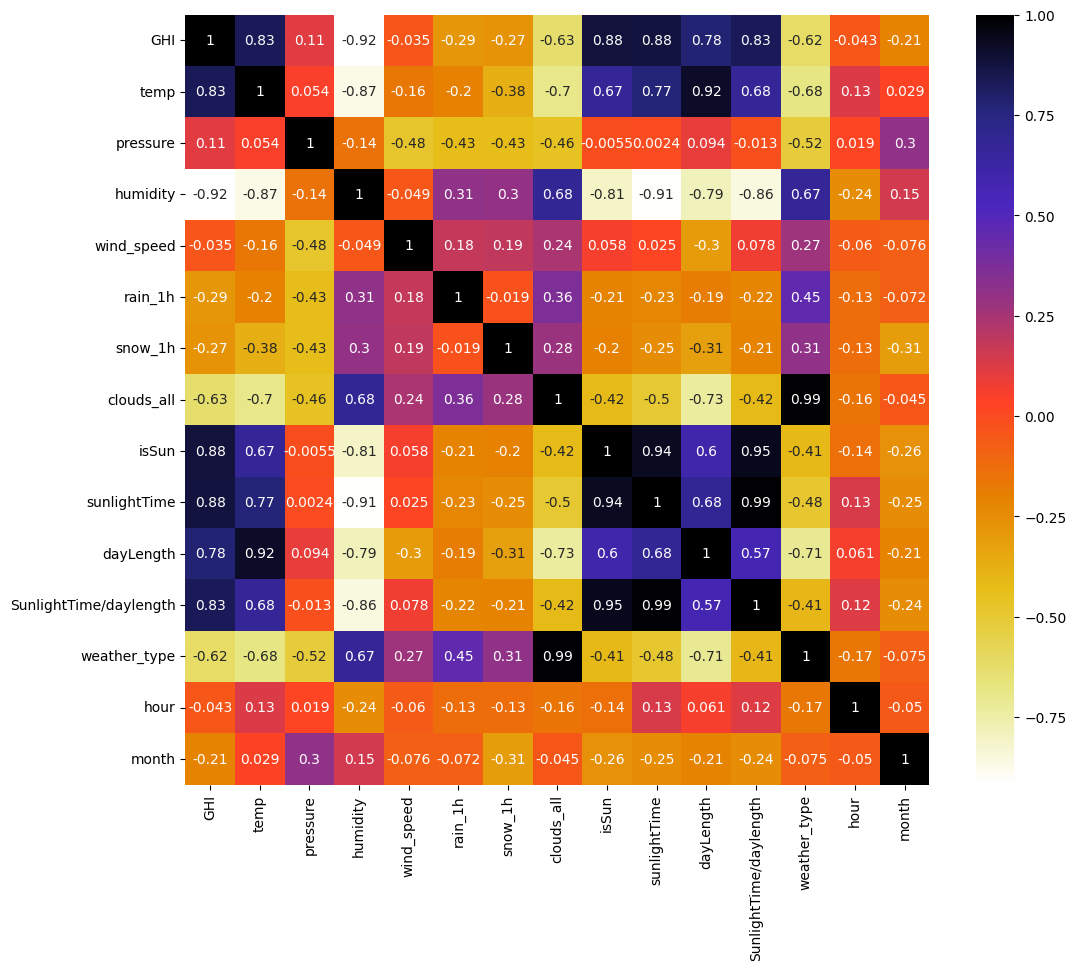

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt
#Using Pearson Correlation
plt.figure(figsize=(12,10))
cor = CorrelationMatrix.corr()
sns.heatmap(cor, annot=True, cmap=plt.cm.CMRmap_r)
plt.show()

In [12]:
def correlation(dataset, threshold):
    col_corr = set()  # Set of all the names of correlated columns
    corr_matrix = dataset.corr()
    for i in range(len(corr_matrix.columns)):
        for j in range(i):
            if abs(corr_matrix.iloc[i, j]) > threshold: # we are interested in absolute coeff value
                colname = corr_matrix.columns[i]  # getting the name of column
                col_corr.add(colname)
    return col_corr


In [13]:
correlation=correlation(X,0.9)
print(correlation)
X=X.drop(correlation,axis=1)
X

{'weather_type', 'SunlightTime/daylength'}


,GHI,temp,pressure,humidity,wind_speed,rain_1h,snow_1h,clouds_all,isSun,sunlightTime,dayLength,hour,month
Time,,,,,,,,,,,,,
2018-01-01 00:00:00,0.0,9.5,997,88,5.8,0.0,0.0,100,0,0,450,0,1
2018-01-01 00:15:00,0.0,9.5,997,88,5.8,0.0,0.0,100,0,0,450,0,1
2018-01-01 00:30:00,0.0,9.5,997,88,5.8,0.0,0.0,100,0,0,450,0,1
2018-01-01 00:45:00,0.0,9.5,997,88,5.8,0.0,0.0,100,0,0,450,0,1
2018-01-01 01:00:00,0.0,9.4,996,87,5.8,0.0,0.0,100,0,0,450,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2018-12-31 22:45:00,0.0,5.4,1024,98,5.4,0.0,0.0,100,0,0,450,22,12
2018-12-31 23:00:00,0.0,5.8,1024,97,5.8,0.0,0.0,100,0,0,450,23,12
2018-12-31 23:15:00,0.0,5.8,1024,97,5.8,0.0,0.0,100,0,0,450,23,12


In [14]:
!pip install mlxtend
!pip install --upgrade scikit-learn mlxtend


In [15]:
import sklearn
from mlxtend.feature_selection import SequentialFeatureSelector
from sklearn.linear_model import LinearRegression

In [16]:
bakward_feature_selector = SequentialFeatureSelector(LinearRegression(n_jobs=1),
                                                    k_features=5,
                                                    forward=False,
                                                    floating=False,
                                                    verbose=2,
                                                    scoring= "r2",
                                                    cv= 5).fit(X,Y)


[2025-01-02 04:28:52] Features: 12/5 -- score: 0.7622514694848299
[2025-01-02 04:28:54] Features: 11/5 -- score: 0.7914463152551081
[2025-01-02 04:28:58] Features: 10/5 -- score: 0.7941994009954383
[2025-01-02 04:29:02] Features: 9/5 -- score: 0.7955959858548929
[2025-01-02 04:29:03] Features: 8/5 -- score: 0.7967338385753966
[2025-01-02 04:29:05] Features: 7/5 -- score: 0.7972634353589627
[2025-01-02 04:29:06] Features: 6/5 -- score: 0.7977398932118565
[2025-01-02 04:29:06] Features: 5/5 -- score: 0.7978746851242705

In [17]:
columns=bakward_feature_selector.k_feature_names_
columns


('GHI', 'temp', 'humidity', 'rain_1h', 'sunlightTime')

In [18]:
bakward_feature_selector.k_score_

0.7978746851242705

In [19]:
X = X[[col for col in X.columns if col in columns]]
X.head()

,GHI,temp,humidity,rain_1h,sunlightTime
Time,,,,,
2018-01-01 00:00:00,0.0,9.5,88,0.0,0
2018-01-01 00:15:00,0.0,9.5,88,0.0,0
2018-01-01 00:30:00,0.0,9.5,88,0.0,0
2018-01-01 00:45:00,0.0,9.5,88,0.0,0
2018-01-01 01:00:00,0.0,9.4,87,0.0,0


In [20]:
print(dataset.head())

                     Energy delta[Wh]  GHI  temp  pressure  humidity  \
Time                                                                   
2017-01-01 00:00:00                 0  0.0   1.6      1021       100   
2017-01-01 00:15:00                 0  0.0   1.6      1021       100   
2017-01-01 00:30:00                 0  0.0   1.6      1021       100   
2017-01-01 00:45:00                 0  0.0   1.6      1021       100   
2017-01-01 01:00:00                 0  0.0   1.7      1020       100   

                     wind_speed  rain_1h  snow_1h  clouds_all  isSun  \
Time                                                                   
2017-01-01 00:00:00         4.9      0.0      0.0         100      0   
2017-01-01 00:15:00         4.9      0.0      0.0         100      0   
2017-01-01 00:30:00         4.9      0.0      0.0         100      0   
2017-01-01 00:45:00         4.9      0.0      0.0         100      0   
2017-01-01 01:00:00         5.2      0.0      0.0         100  

In [21]:
!pip install statsmodels

# ***ARIMA MODEL***

In [22]:
from sklearn.model_selection import train_test_split
X_train_A,X_test_A,Y_train_A,Y_test_A=train_test_split(X, Y, test_size=0.2, random_state=1, shuffle=False);
X_train_A.shape,X_test_A.shape

((28032, 5), (7008, 5))

In [23]:
Y_train_A

,Energy delta[MWh]
Time,
2018-01-01 00:00:00,0.0
2018-01-01 00:15:00,0.0
2018-01-01 00:30:00,0.0
2018-01-01 00:45:00,0.0
2018-01-01 01:00:00,0.0
...,...
2018-10-19 22:45:00,0.0
2018-10-19 23:00:00,0.0
2018-10-19 23:15:00,0.0


In [24]:

from statsmodels.tsa.stattools import adfuller
def adf_test(dataset):
    dftest=adfuller(dataset,autolag='AIC')
    print("1. ADF : ",dftest[0])
    print("2. P-Value : ", dftest[1])
    print("3. Num Of Lags : ", dftest[2])
    print("4. Num Of Observations Used For ADF Regression and Critical Values Calculation :", dftest[3])
    print("5. Critical Values :")
    for key, val in dftest[4].items():
        print("\t",key, ": ", val)



adf_test(Y_train_A)

1. ADF :  -31.460670164138214
2. P-Value :  0.0
3. Num Of Lags :  50
4. Num Of Observations Used For ADF Regression and Critical Values Calculation : 27981
5. Critical Values :
	 1% :  -3.430583726457544
	 5% :  -2.8616433005027737
	 10% :  -2.5668249837528876


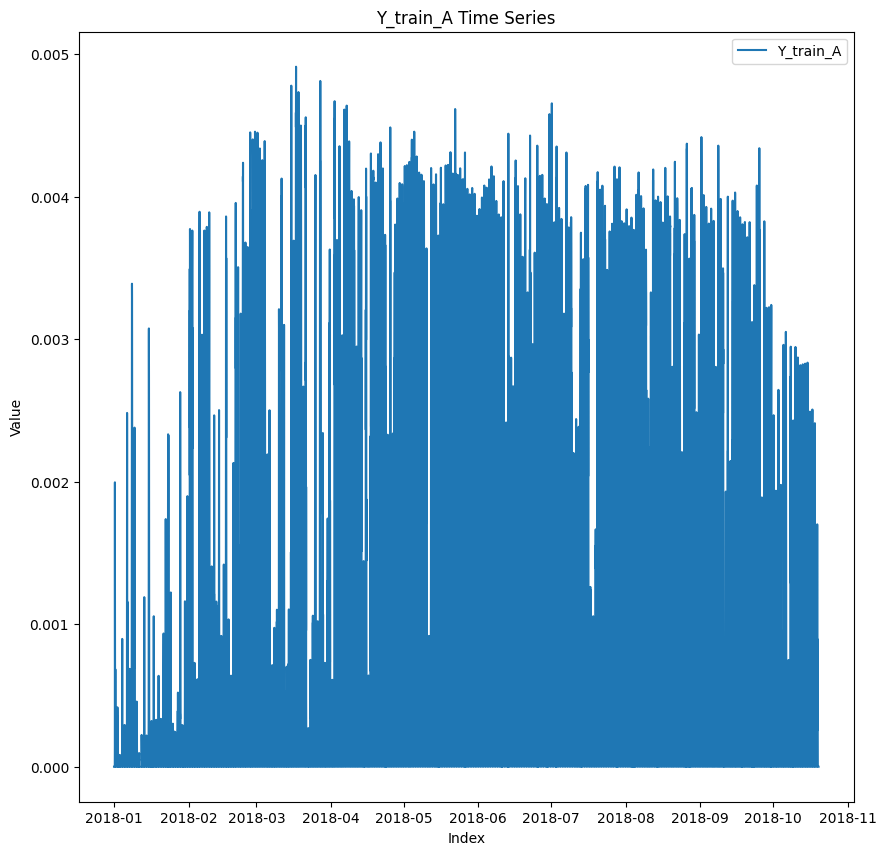

In [25]:
plt.figure(figsize=(10, 10))  # Width = 20, Height = 10
start_time='2018-02-01'
end_time='2017-11-01'

# Plot the data
plot_data=Y_train_A
plot_data = plot_data[~((Y_train_A.index >= start_time) & (Y_train_A.index <= end_time))]
plt.plot(plot_data, label="Y_train_A")
plt.title("Y_train_A Time Series")
plt.xlabel("Index")
plt.ylabel("Value")
plt.legend()

# Show the plot
plt.show()

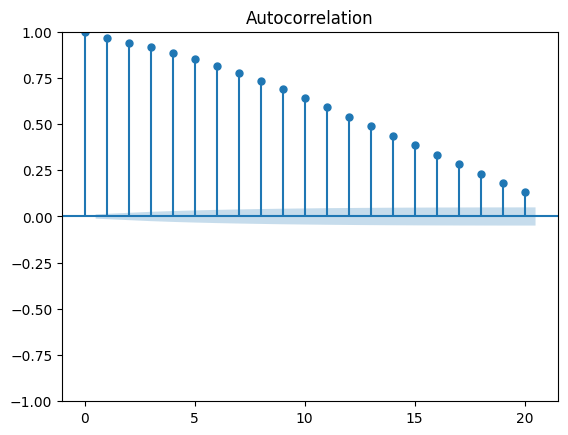

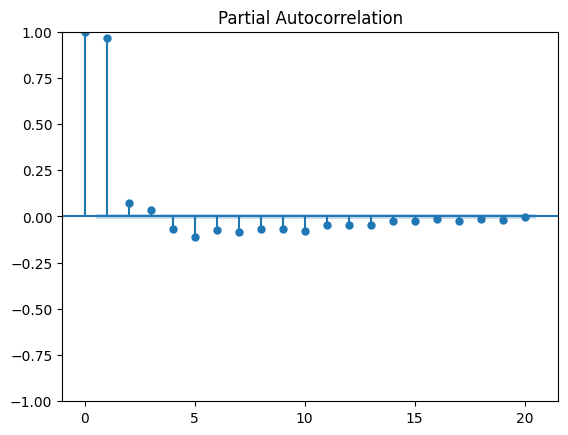

In [26]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
plot_acf(Y_train_A, lags=20)
plt.show()
plot_pacf(Y_train_A, lags=20)
plt.show()

In [27]:
Y_train_A=Y_train_A.to_frame()

Y_train_A

,Energy delta[MWh]
Time,
2018-01-01 00:00:00,0.0
2018-01-01 00:15:00,0.0
2018-01-01 00:30:00,0.0
2018-01-01 00:45:00,0.0
2018-01-01 01:00:00,0.0
...,...
2018-10-19 22:45:00,0.0
2018-10-19 23:00:00,0.0
2018-10-19 23:15:00,0.0


In [28]:
Y_train_A_2=Y_train_A.diff().dropna()
Y_train_A_2

,Energy delta[MWh]
Time,
2018-01-01 00:15:00,0.0
2018-01-01 00:30:00,0.0
2018-01-01 00:45:00,0.0
2018-01-01 01:00:00,0.0
2018-01-01 01:15:00,0.0
...,...
2018-10-19 22:45:00,0.0
2018-10-19 23:00:00,0.0
2018-10-19 23:15:00,0.0


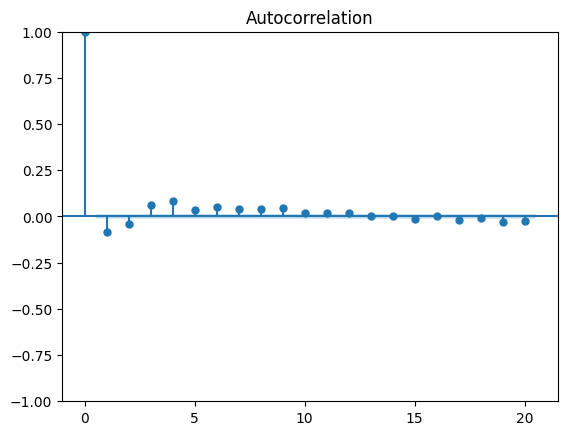

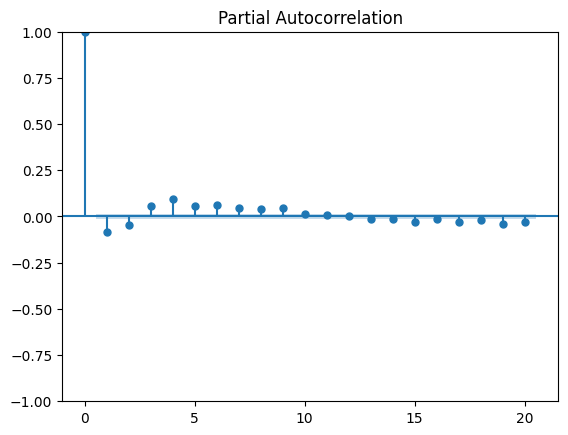

In [29]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
plot_acf(Y_train_A_2, lags=20)
plt.show()
plot_pacf(Y_train_A_2, lags=20)
plt.show()

In [30]:
adf_test(Y_train_A_2)

1. ADF :  -32.52702724210631
2. P-Value :  0.0
3. Num Of Lags :  50
4. Num Of Observations Used For ADF Regression and Critical Values Calculation : 27980
5. Critical Values :
	 1% :  -3.4305837348116506
	 5% :  -2.861643304194908
	 10% :  -2.566824985718125


In [31]:
Y_train_A.tail()

,Energy delta[MWh]
Time,
2018-10-19 22:45:00,0.0
2018-10-19 23:00:00,0.0
2018-10-19 23:15:00,0.0
2018-10-19 23:30:00,0.0
2018-10-19 23:45:00,0.0


In [32]:
!pip install pmdarima

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 21.5 MB/s eta 0:00:00


In [33]:
# from pmdarima import auto_arima

# stepwise_fit = auto_arima(Y_train_A,
#                           seasonal=True,
#                           m=12,  # Set the seasonal period (S)
#                           trace=True,
#                           suppress_warnings=True)
# #
# print(stepwise_fit.summary())


In [34]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Define the SARIMAX model
modelA = SARIMAX(Y_train_A_2['Energy delta[MWh]'].diff().dropna(),
                order=(2,1,2),  # ARIMA order
                seasonal_order=(2,0,2, 12),
                enforce_stationarity=True,
                enforce_invertibility=True)

# Fit the model
modelA = modelA.fit()

# Print the summary of the fitted model
print(modelA.summary())

/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency 15min will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency 15min will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/usr/local/lib/python3.10/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


                                     SARIMAX Results                                      
Dep. Variable:                  Energy delta[MWh]   No. Observations:                28030
Model:             SARIMAX(2, 1, 2)x(2, 0, 2, 12)   Log Likelihood              172505.724
Date:                            Thu, 02 Jan 2025   AIC                        -344993.448
Time:                                    04:31:30   BIC                        -344919.279
Sample:                                01-01-2018   HQIC                       -344969.573
                                     - 10-19-2018                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.8517      0.001   -961.278      0.000      -0.853      -0.850
ar.L2         -0.2918      0.002   

In [35]:
start=len(Y_train_A)
end=len(Y_train_A)+len(Y_test_A)-1
start,end

(28032, 35039)

/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/statespace/representation.py:374: FutureWarning: Unknown keyword arguments: dict_keys(['typ']).Passing unknown keyword arguments will raise a TypeError beginning in version 0.15.
  warnings.warn(msg, FutureWarning)
<ipython-input-36-a2167cb8d0ac>:12: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  index_future_dates = pd.date_range(start='2018-10-20', periods=len(pred), freq='15T')


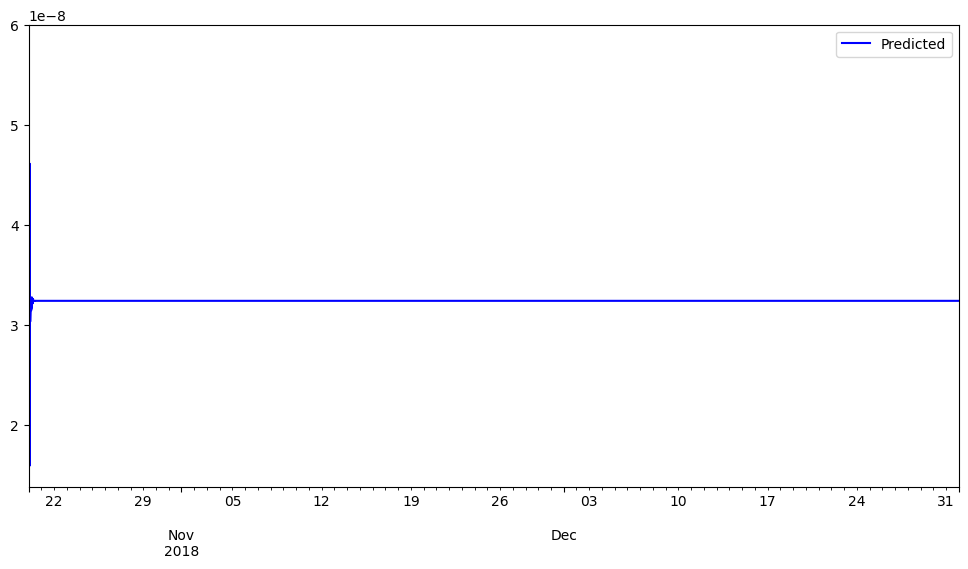

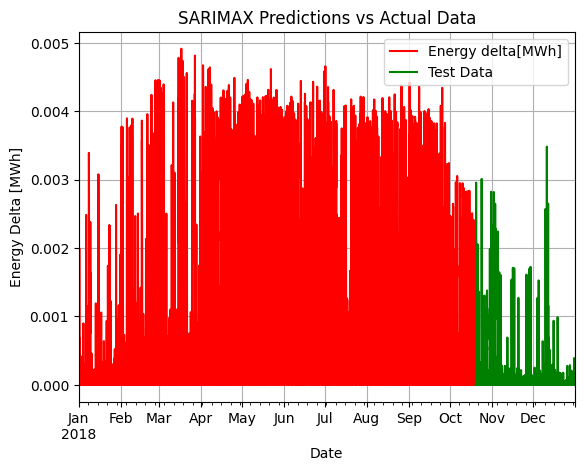

2018-10-20 00:00:00    5.796681e-08
2018-10-20 00:15:00    3.422652e-08
2018-10-20 00:30:00    4.360405e-08
2018-10-20 00:45:00    2.801918e-08
2018-10-20 01:00:00    3.894957e-08
                           ...     
2018-12-31 22:45:00    3.241093e-08
2018-12-31 23:00:00    3.241093e-08
2018-12-31 23:15:00    3.241093e-08
2018-12-31 23:30:00    3.241093e-08
2018-12-31 23:45:00    3.241093e-08
Freq: 15min, Name: SARIMAX predictions, Length: 7008, dtype: float64
Time
2018-10-20 00:00:00    0.0
2018-10-20 00:15:00    0.0
2018-10-20 00:30:00    0.0
2018-10-20 00:45:00    0.0
2018-10-20 01:00:00    0.0
                      ... 
2018-12-31 22:45:00    0.0
2018-12-31 23:00:00    0.0
2018-12-31 23:15:00    0.0
2018-12-31 23:30:00    0.0
2018-12-31 23:45:00    0.0
Name: Energy delta[MWh], Length: 7008, dtype: float64


In [36]:
import matplotlib.pyplot as plt
import pandas as pd

# Define the start and end indices for the prediction
start = len(Y_train_A)
end = len(Y_train_A) + len(Y_test_A) - 1

# Generate predictions
pred = modelA.predict(start=start, end=end, typ='levels').rename('SARIMAX predictions')

# Create a future date range for the prediction (ensure it's in the correct frequency)
index_future_dates = pd.date_range(start='2018-10-20', periods=len(pred), freq='15T')

# Set the prediction index to the future dates
pred.index = index_future_dates

# Plot both the predicted and actual values on the same graph
plt.figure(figsize=(12, 6))
pred.plot(legend=True, label='Predicted', color='blue')
Y_train_A.plot(legend=True, color='red', label='Training Data')
Y_test_A.plot(legend=True, color='green', label='Test Data')

# Labels and title for the graph
plt.xlabel('Date')
plt.ylabel('Energy Delta [MWh]')
plt.title('SARIMAX Predictions vs Actual Data')

# Display the plot
plt.grid(True)
plt.show()

# Print predictions and actual values for verification
print(pred)
print(Y_test_A)


# **LSTM MODEL**

In [37]:
X_L=X
Y_L=Y
X.shape
st_time='2018-01-01'
X_L

,GHI,temp,humidity,rain_1h,sunlightTime
Time,,,,,
2018-01-01 00:00:00,0.0,9.5,88,0.0,0
2018-01-01 00:15:00,0.0,9.5,88,0.0,0
2018-01-01 00:30:00,0.0,9.5,88,0.0,0
2018-01-01 00:45:00,0.0,9.5,88,0.0,0
2018-01-01 01:00:00,0.0,9.4,87,0.0,0
...,...,...,...,...,...
2018-12-31 22:45:00,0.0,5.4,98,0.0,0
2018-12-31 23:00:00,0.0,5.8,97,0.0,0
2018-12-31 23:15:00,0.0,5.8,97,0.0,0


In [38]:
from sklearn.preprocessing import MinMaxScaler

In [39]:
X_L

,GHI,temp,humidity,rain_1h,sunlightTime
Time,,,,,
2018-01-01 00:00:00,0.0,9.5,88,0.0,0
2018-01-01 00:15:00,0.0,9.5,88,0.0,0
2018-01-01 00:30:00,0.0,9.5,88,0.0,0
2018-01-01 00:45:00,0.0,9.5,88,0.0,0
2018-01-01 01:00:00,0.0,9.4,87,0.0,0
...,...,...,...,...,...
2018-12-31 22:45:00,0.0,5.4,98,0.0,0
2018-12-31 23:00:00,0.0,5.8,97,0.0,0
2018-12-31 23:15:00,0.0,5.8,97,0.0,0


In [40]:
#normalizing the data
scaler = MinMaxScaler()
# Convert Series to DataFrame
Y_L = Y_L.to_frame()
X_L=pd.concat([X_L,Y_L],axis=1)

scaled_values = scaler.fit_transform(X_L)
scaled_values.shape


(35040, 6)

In [41]:
X_L
features_col=X_L.columns
print(features_col)

Index(['GHI', 'temp', 'humidity', 'rain_1h', 'sunlightTime',
       'Energy delta[MWh]'],
      dtype='object')


In [42]:
Y_L

,Energy delta[MWh]
Time,
2018-01-01 00:00:00,0.0
2018-01-01 00:15:00,0.0
2018-01-01 00:30:00,0.0
2018-01-01 00:45:00,0.0
2018-01-01 01:00:00,0.0
...,...
2018-12-31 22:45:00,0.0
2018-12-31 23:00:00,0.0
2018-12-31 23:15:00,0.0


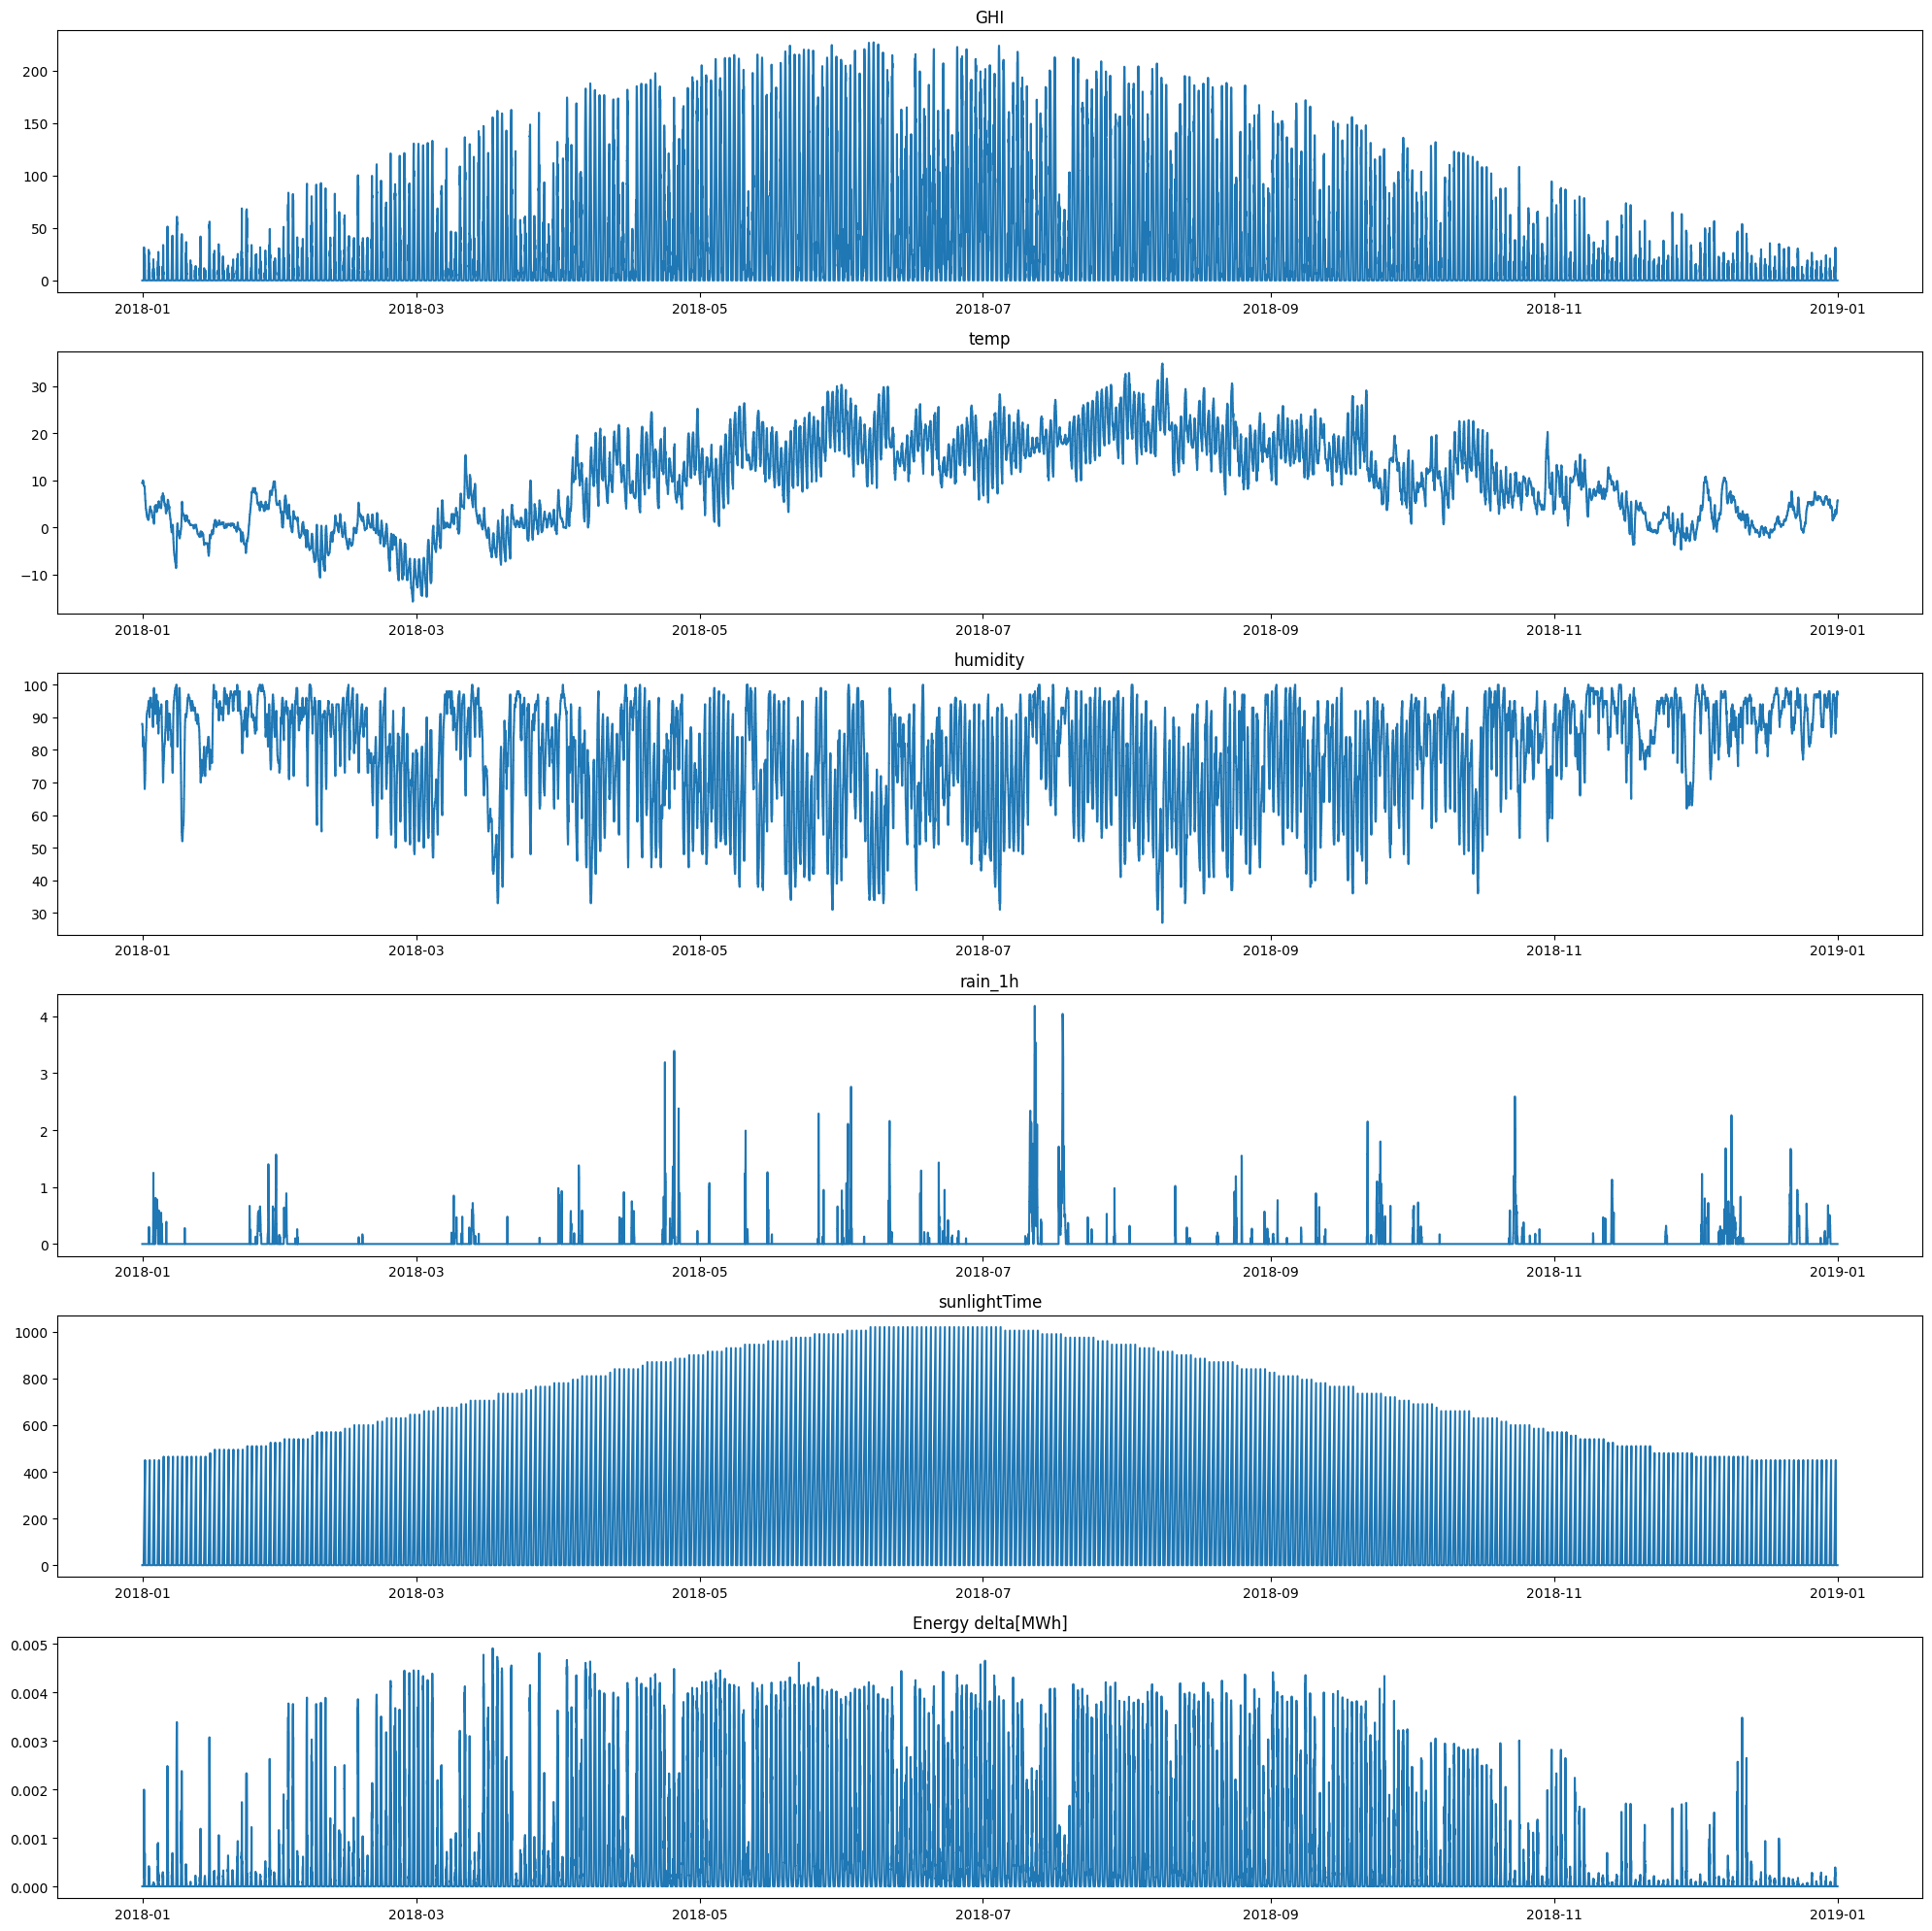

In [43]:
figure, axes = plt.subplots(len(X_L.columns),1,figsize=(20, 20))
start_time = pd.to_datetime('2018-01-01')
end_time = pd.to_datetime('2018-12-31')

for ax,col in zip(axes,X_L.columns):
    ax.plot(X_L[col])
    ax.set_title(col)
    ax.axes.xaxis.set_visible(True)


plt.tight_layout()
plt.show()


In [44]:
import numpy as np

def create_sequence(data, window_size):
    X = []
    y = []
    for i in range(window_size, len(data)):
        # Use numpy slicing instead of iloc
        X.append(data[i-window_size:i])  # Use array slicing
        y.append(data[i])  # Target value for this sequence
    return np.array(X), np.array(y)

X_L_scaled, Y_L_scaled = create_sequence(scaled_values, 60)

# Print the first sequence and corresponding target



In [45]:
import tensorflow as tf


# Ensure that TensorFlow uses GPU and sets memory growth
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        # Set memory growth for all GPUs (or specific ones)
        tf.config.experimental.set_memory_growth(gpus[0], True)
        print("GPU memory growth set successfully")
    except RuntimeError as e:
        print(e)
else:
    print("No GPUs detected, using CPU")

from tensorflow.keras import Sequential
from tensorflow.keras.layers import LSTM, Dropout, Dense

No GPUs detected, using CPU


In [46]:
X_L_scaled.shape[1], X_L_scaled.shape[2]

(60, 6)

In [47]:
Y_L_scaled.shape[1]

6

In [48]:
modelL = Sequential([
    # Adding the first LSTM layer with Dropout
    LSTM(units=50, input_shape=(X_L_scaled.shape[1], X_L_scaled.shape[2])),
    Dropout(0.3),
    # Adding a Dense output layer
    Dense(Y_L_scaled.shape[1])
])

/usr/local/lib/python3.10/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [49]:
#compilation
modelL.compile(optimizer = 'adam',
              loss = 'mean_squared_error',
              metrics = ['RootMeanSquaredError'])


In [50]:
#train-test-split

X_train_L, X_test_L, y_train_L, y_test_L = train_test_split(X_L_scaled, Y_L_scaled, test_size = 0.2, random_state=42,shuffle=False)
X_train_L.shape, y_train_L.shape, X_test_L.shape, y_test_L.shape

((27984, 60, 6), (27984, 6), (6996, 60, 6), (6996, 6))

In [51]:
Y_L_scaled

array([[0.        , 0.42376238, 0.63013699, 0.        , 0.        ,
        0.        ],
       [0.        , 0.42376238, 0.63013699, 0.        , 0.        ,
        0.        ],
       [0.        , 0.42376238, 0.63013699, 0.        , 0.        ,
        0.        ],
       ...,
       [0.        , 0.42574257, 0.95890411, 0.        , 0.        ,
        0.        ],
       [0.        , 0.42574257, 0.95890411, 0.        , 0.        ,
        0.        ],
       [0.        , 0.42574257, 0.95890411, 0.        , 0.        ,
        0.        ]])

In [52]:
history = modelL.fit(X_train_L, y_train_L,
                    validation_split=0.2,
                    epochs=8,
                    batch_size=1,
                    verbose=1)

Epoch 1/8
22387/22387 ━━━━━━━━━━━━━━━━━━━━ 262s 12ms/step - RootMeanSquaredError: 0.0958 - loss: 0.0101 - val_RootMeanSquaredError: 0.0473 - val_loss: 0.0022
Epoch 2/8
22387/22387 ━━━━━━━━━━━━━━━━━━━━ 259s 12ms/step - RootMeanSquaredError: 0.0625 - loss: 0.0039 - val_RootMeanSquaredError: 0.0419 - val_loss: 0.0018
Epoch 3/8
22387/22387 ━━━━━━━━━━━━━━━━━━━━ 257s 11ms/step - RootMeanSquaredError: 0.0609 - loss: 0.0037 - val_RootMeanSquaredError: 0.0403 - val_loss: 0.0016
Epoch 4/8
22387/22387 ━━━━━━━━━━━━━━━━━━━━ 264s 12ms/step - RootMeanSquaredError: 0.0593 - loss: 0.0035 - val_RootMeanSquaredError: 0.0397 - val_loss: 0.0016
Epoch 5/8
22387/22387 ━━━━━━━━━━━━━━━━━━━━ 268s 12ms/step - RootMeanSquaredError: 0.0585 - loss: 0.0034 - val_RootMeanSquaredError: 0.0402 - val_loss: 0.0016
Epoch 6/8
22387/22387 ━━━━━━━━━━━━━━━━━━━━ 314s 11ms/step - RootMeanSquaredError: 0.0584 - loss: 0.0034 - val_RootMeanSquaredError: 0.0386 - val_loss: 0.0015
Epoch 7/8
22387/22387 ━━━━━━━━━━━━━━━━━━━━ 259s 11ms

In [53]:
X_test_L.size

2518560

In [54]:

y_test_L=scaler.inverse_transform(y_test_L)


In [55]:
y_test_L

array([[ 0. ,  3.5, 94. ,  0. ,  0. ,  0. ],
       [ 0. ,  3.5, 94. ,  0. ,  0. ,  0. ],
       [ 0. ,  3.5, 94. ,  0. ,  0. ,  0. ],
       ...,
       [ 0. ,  5.8, 97. ,  0. ,  0. ,  0. ],
       [ 0. ,  5.8, 97. ,  0. ,  0. ,  0. ],
       [ 0. ,  5.8, 97. ,  0. ,  0. ,  0. ]])

In [56]:
y_test_L = pd.DataFrame(y_test_L)
y_test_inv_df =y_test_L
y_test_inv_df.columns=X_L.columns

y_test_inv_df.index = X_L.index[-len(y_test_L):]

print(y_test_inv_df)


                     GHI  temp  humidity  rain_1h  sunlightTime  \
Time                                                              
2018-10-20 03:00:00  0.0   3.5      94.0      0.0           0.0   
2018-10-20 03:15:00  0.0   3.5      94.0      0.0           0.0   
2018-10-20 03:30:00  0.0   3.5      94.0      0.0           0.0   
2018-10-20 03:45:00  0.0   3.5      94.0      0.0           0.0   
2018-10-20 04:00:00  0.0   4.2      93.0      0.0           0.0   
...                  ...   ...       ...      ...           ...   
2018-12-31 22:45:00  0.0   5.4      98.0      0.0           0.0   
2018-12-31 23:00:00  0.0   5.8      97.0      0.0           0.0   
2018-12-31 23:15:00  0.0   5.8      97.0      0.0           0.0   
2018-12-31 23:30:00  0.0   5.8      97.0      0.0           0.0   
2018-12-31 23:45:00  0.0   5.8      97.0      0.0           0.0   

                     Energy delta[MWh]  
Time                                    
2018-10-20 03:00:00                0.0  
2018-

In [57]:
X_test_L.shape

(6996, 60, 6)

In [58]:
yPred=modelL.predict(X_test_L)
yPred

219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step


array([[ 4.7200769e-03,  3.7118286e-01,  9.6610600e-01,  7.2283885e-03,
         3.8158894e-04,  1.7004326e-02],
       [ 4.0087849e-03,  3.7664834e-01,  9.3900484e-01,  5.1651839e-03,
        -1.9159913e-03,  1.5145794e-02],
       [ 1.0285631e-02,  3.7955749e-01,  9.2189711e-01,  4.7879368e-03,
         2.9847026e-03,  1.9473389e-02],
       ...,
       [ 6.8862289e-03,  4.2351097e-01,  9.5853478e-01,  6.6225082e-03,
         2.4034977e-03,  1.7159328e-02],
       [ 7.2771460e-03,  4.2503381e-01,  9.5434129e-01,  6.5516252e-03,
         2.4373531e-03,  1.7236531e-02],
       [ 6.9442838e-03,  4.2611444e-01,  9.5074493e-01,  6.9299117e-03,
         1.8919408e-03,  1.7069623e-02]], dtype=float32)

In [59]:
yPred.shape

(6996, 6)

In [60]:
yPred

array([[ 4.7200769e-03,  3.7118286e-01,  9.6610600e-01,  7.2283885e-03,
         3.8158894e-04,  1.7004326e-02],
       [ 4.0087849e-03,  3.7664834e-01,  9.3900484e-01,  5.1651839e-03,
        -1.9159913e-03,  1.5145794e-02],
       [ 1.0285631e-02,  3.7955749e-01,  9.2189711e-01,  4.7879368e-03,
         2.9847026e-03,  1.9473389e-02],
       ...,
       [ 6.8862289e-03,  4.2351097e-01,  9.5853478e-01,  6.6225082e-03,
         2.4034977e-03,  1.7159328e-02],
       [ 7.2771460e-03,  4.2503381e-01,  9.5434129e-01,  6.5516252e-03,
         2.4373531e-03,  1.7236531e-02],
       [ 6.9442838e-03,  4.2611444e-01,  9.5074493e-01,  6.9299117e-03,
         1.8919408e-03,  1.7069623e-02]], dtype=float32)

In [61]:
yPred = pd.DataFrame(yPred)
y_pred_inv_df =yPred
y_pred_inv_df.columns=X_L.columns

y_pred_inv_df.index = X_L.index[-len(y_test_L):]

print(y_pred_inv_df)


                          GHI      temp  humidity   rain_1h  sunlightTime  \
Time                                                                        
2018-10-20 03:00:00  0.004720  0.371183  0.966106  0.007228      0.000382   
2018-10-20 03:15:00  0.004009  0.376648  0.939005  0.005165     -0.001916   
2018-10-20 03:30:00  0.010286  0.379557  0.921897  0.004788      0.002985   
2018-10-20 03:45:00  0.007268  0.382493  0.909873  0.006324      0.000747   
2018-10-20 04:00:00  0.008047  0.384613  0.905971  0.006913      0.001017   
...                       ...       ...       ...       ...           ...   
2018-12-31 22:45:00  0.006031  0.418583  0.965612  0.007290      0.001072   
2018-12-31 23:00:00  0.005277  0.418003  0.966684  0.007127      0.001386   
2018-12-31 23:15:00  0.006886  0.423511  0.958535  0.006623      0.002403   
2018-12-31 23:30:00  0.007277  0.425034  0.954341  0.006552      0.002437   
2018-12-31 23:45:00  0.006944  0.426114  0.950745  0.006930      0.001892   

In [62]:
y_pred_inv_df=scaler.inverse_transform(y_pred_inv_df)

In [63]:
y_pred_inv_df=pd.DataFrame(y_pred_inv_df)
y_pred_inv_df.columns=X_L.columns

y_pred_inv_df.index = X_L.index[-len(y_test_L):]

print(y_pred_inv_df)

                          GHI      temp   humidity   rain_1h  sunlightTime  \
Time                                                                         
2018-10-20 03:00:00  1.071929  3.044734  97.525734  0.030215      0.389221   
2018-10-20 03:15:00  0.910395  3.320741  95.547348  0.021590     -1.954311   
2018-10-20 03:30:00  2.335867  3.467653  94.298485  0.020014      3.044397   
2018-10-20 03:45:00  1.650589  3.615875  93.420738  0.026436      0.761753   
2018-10-20 04:00:00  1.827467  3.722961  93.135857  0.028896      1.037527   
...                       ...       ...        ...       ...           ...   
2018-12-31 22:45:00  1.369570  5.438422  97.489708  0.030471      1.093703   
2018-12-31 23:00:00  1.198368  5.409162  97.567940  0.029789      1.413251   
2018-12-31 23:15:00  1.563863  5.687304  96.973038  0.027682      2.451568   
2018-12-31 23:30:00  1.652640  5.764207  96.666916  0.027386      2.486100   
2018-12-31 23:45:00  1.577047  5.818779  96.404373  0.028967    

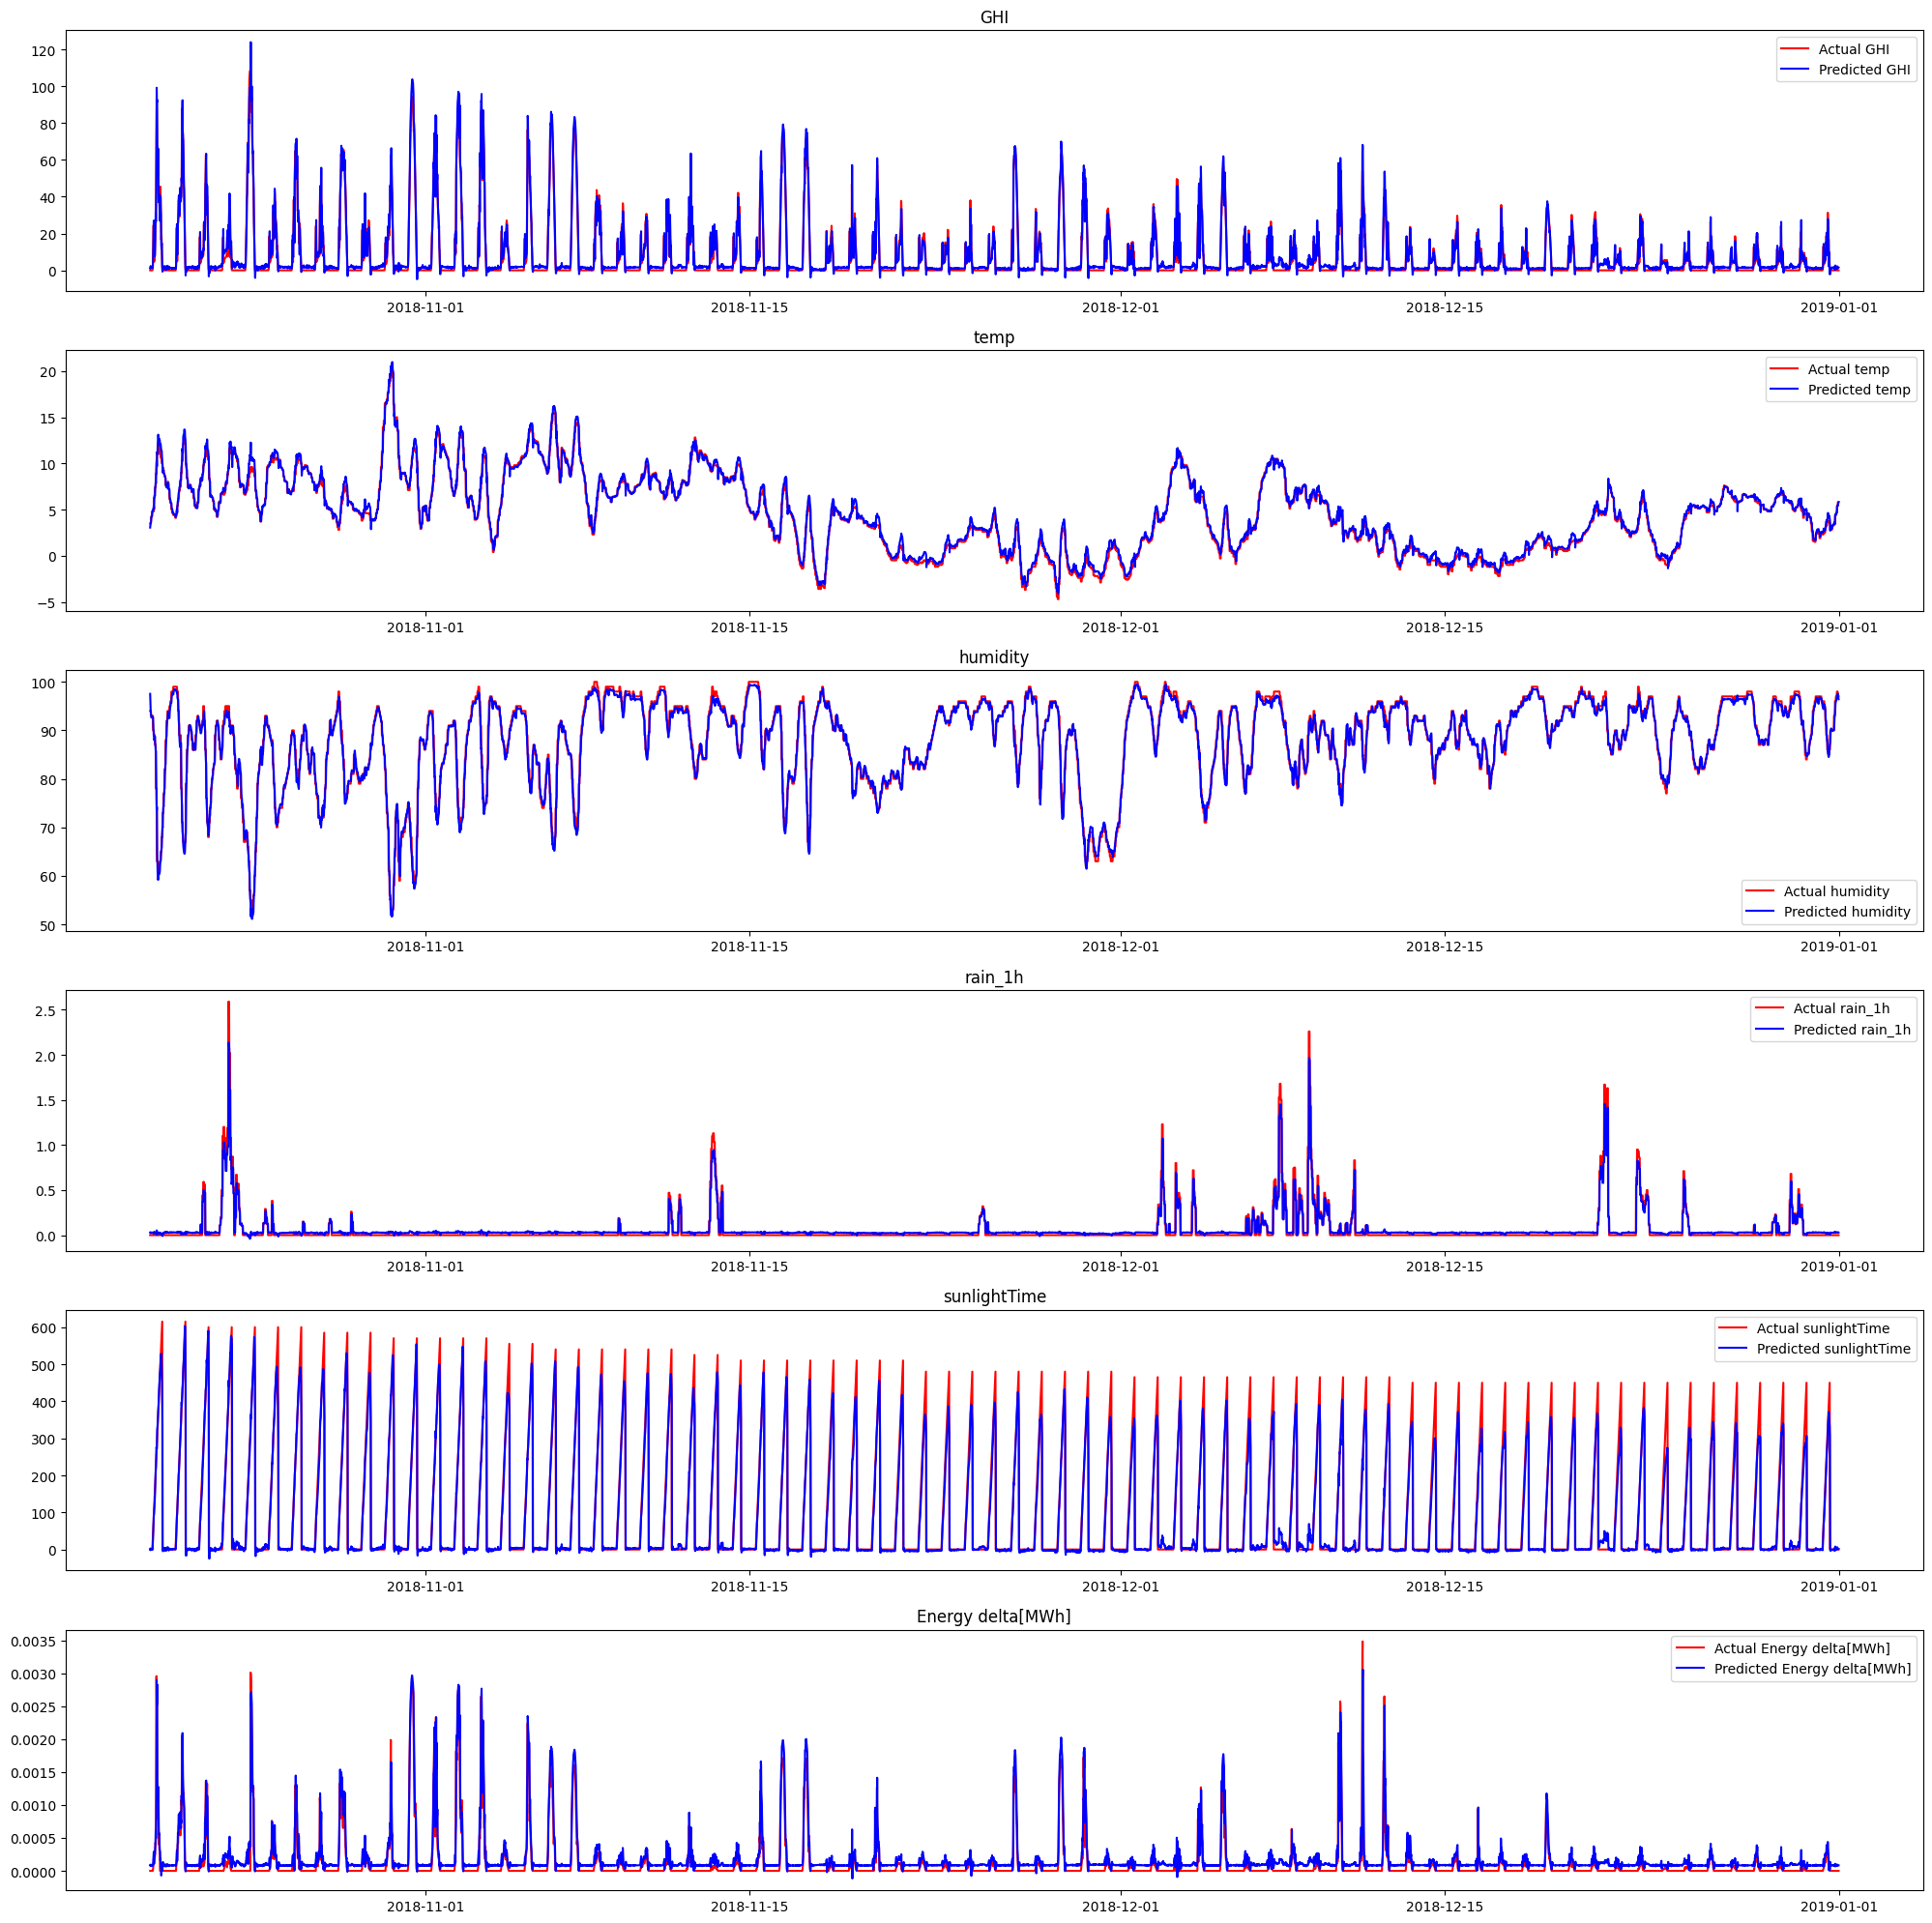

In [64]:
fig ,axes=plt.subplots(len(y_test_L.columns),1,figsize=(20,20))
for ax,col in zip(axes,y_test_L.columns):
    ax.plot(y_test_L[col],color='red',label=f'Actual {col}')
    ax.plot(y_pred_inv_df[col],color='blue',label=f'Predicted {col}')
    ax.legend()
    ax.set_title(col)
    ax.set_title(col)

plt.tight_layout()
plt.show()


# ***VAR***

In [65]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.varmax import VARMAX
from statsmodels.tsa.api import VAR
from statsmodels.tsa.stattools import grangercausalitytests, adfuller
from tqdm import tqdm_notebook
from itertools import product

import matplotlib.pyplot as plt
import statsmodels.api as sm
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import warnings
warnings.filterwarnings('ignore')


In [66]:
X_V=X
Y_V=Y
print(X_V)

                     GHI  temp  humidity  rain_1h  sunlightTime
Time                                                           
2018-01-01 00:00:00  0.0   9.5        88      0.0             0
2018-01-01 00:15:00  0.0   9.5        88      0.0             0
2018-01-01 00:30:00  0.0   9.5        88      0.0             0
2018-01-01 00:45:00  0.0   9.5        88      0.0             0
2018-01-01 01:00:00  0.0   9.4        87      0.0             0
...                  ...   ...       ...      ...           ...
2018-12-31 22:45:00  0.0   5.4        98      0.0             0
2018-12-31 23:00:00  0.0   5.8        97      0.0             0
2018-12-31 23:15:00  0.0   5.8        97      0.0             0
2018-12-31 23:30:00  0.0   5.8        97      0.0             0
2018-12-31 23:45:00  0.0   5.8        97      0.0             0

[35040 rows x 5 columns]


In [67]:
#normalizing the data
scaler = MinMaxScaler()
# Convert Series to DataFrame
Y_V = Y_V.to_frame()
X_V=pd.concat([X_V,Y_V],axis=1)

scaled_values = scaler.fit_transform(X_V)
scaled_values.shape


(35040, 6)

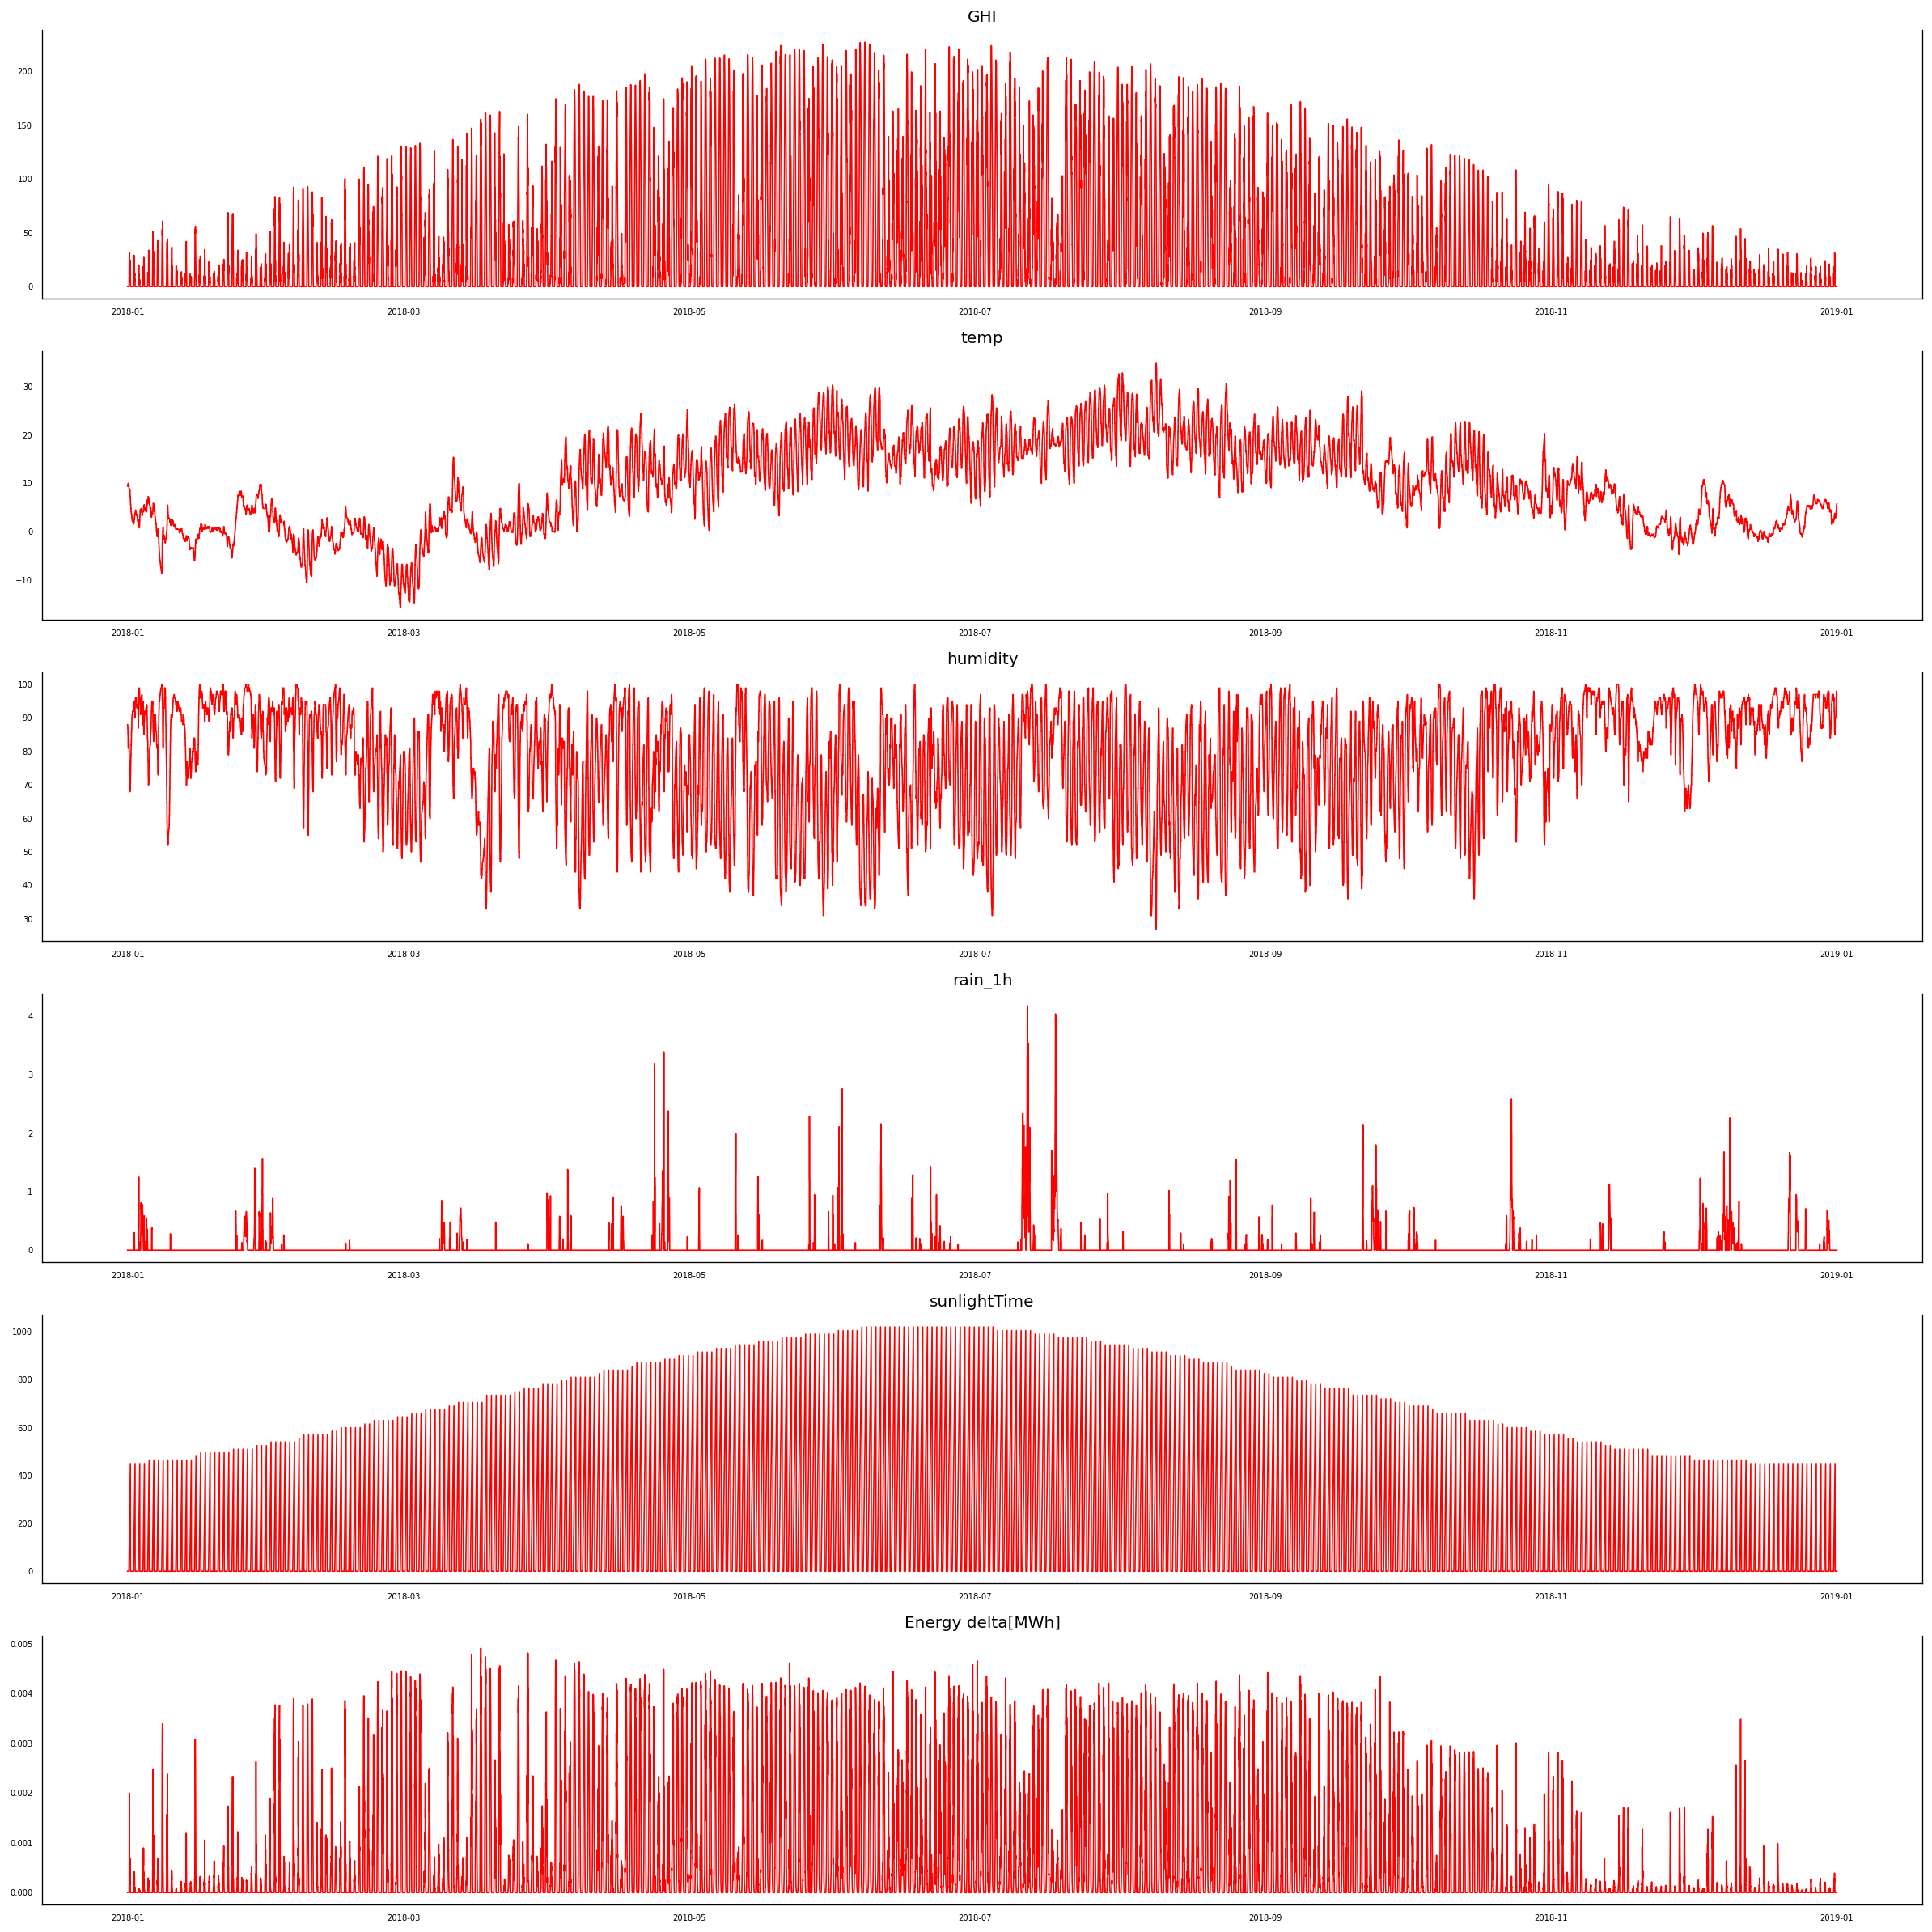

In [68]:
fig, axes = plt.subplots(nrows=len(X_V.columns), ncols=1, dpi=120, figsize=(20,20))
for i, ax in enumerate(axes.flatten()):
    data = X_V[X_V.columns[i]]
    ax.plot(data, color='red', linewidth=1)
    # Decorations
    ax.set_title(X_V.columns[i])
    ax.xaxis.set_ticks_position('none')
    ax.yaxis.set_ticks_position('none')
    ax.spines["top"].set_alpha(0)
    ax.tick_params(labelsize=6)

plt.tight_layout();

In [69]:
for i in range(len(X_V.columns)):
  ad_fuller_result_i = adfuller(X_V[X_V.columns[i]])
  print(X_V.columns[i])
  print(f'ADF Statistic: {ad_fuller_result_i[0]}')
  print(f'p-value: {ad_fuller_result_i[1]}')
  print('--------------------------')


GHI
ADF Statistic: -34.709217369156065
p-value: 0.0
--------------------------
temp
ADF Statistic: -4.024641889548555
p-value: 0.0012868357939684189
--------------------------
humidity
ADF Statistic: -11.039016808405558
p-value: 5.425012379751475e-20
--------------------------
rain_1h
ADF Statistic: -17.073052333636134
p-value: 7.801037078138724e-30
--------------------------
sunlightTime
ADF Statistic: -33.1874089146562
p-value: 0.0
--------------------------
Energy delta[MWh]
ADF Statistic: -31.16790879523256
p-value: 0.0
--------------------------


In [70]:
X_train, X_test, y_train, y_test = train_test_split(X_V,Y_V, test_size = 0.2, random_state=42,shuffle=False)
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((28032, 6), (28032, 1), (7008, 6), (7008, 1))

In [71]:
X_train

,GHI,temp,humidity,rain_1h,sunlightTime,Energy delta[MWh]
Time,,,,,,
2018-01-01 00:00:00,0.0,9.5,88,0.0,0,0.0
2018-01-01 00:15:00,0.0,9.5,88,0.0,0,0.0
2018-01-01 00:30:00,0.0,9.5,88,0.0,0,0.0
2018-01-01 00:45:00,0.0,9.5,88,0.0,0,0.0
2018-01-01 01:00:00,0.0,9.4,87,0.0,0,0.0
...,...,...,...,...,...,...
2018-10-19 22:45:00,0.0,5.6,100,0.0,0,0.0
2018-10-19 23:00:00,0.0,5.2,100,0.0,0,0.0
2018-10-19 23:15:00,0.0,5.2,100,0.0,0,0.0


In [72]:
from statsmodels.tsa.api import VAR

# 1. Fit the VAR model with automatic lag selection
modelV = VAR(X_train)  # X_train is your input data
lag_order = modelV.select_order(maxlags=5)  # Check up to 15 lags
print(lag_order.summary())

# 2. Use the best lag (e.g., based on AIC)
best_lag = 5
fitted_model = modelV.fit(maxlags=best_lag)
start=len(X_train)
end=len(X_train)+len(X_test)-1


# 3. Forecast future values
n_forecast_steps = 10  # Number of time steps to forecast
last_lagged_values = X_train.values[-best_lag:]
forecast = fitted_model.forecast(y=last_lagged_values, steps=len(X_train))

print("Forecasted Values:")
print(forecast)


 VAR Order Selection (* highlights the minimums) 
      AIC         BIC         FPE         HQIC   
-------------------------------------------------
0       9.639       9.641   1.535e+04       9.639
1      -9.232      -9.219   9.789e-05      -9.228
2      -9.424      -9.401   8.076e-05      -9.417
3      -9.530      -9.497   7.263e-05      -9.519
4      -9.634      -9.590   6.545e-05      -9.620
5     -10.47*     -10.41*  2.841e-05*     -10.45*
-------------------------------------------------
Forecasted Values:
[[1.55755251e+00 5.08658701e+00 1.00191125e+02 1.16543647e-02
  8.28560702e+00 1.99566093e-05]
 [3.90527262e+00 5.14799805e+00 9.98815080e+01 1.56326933e-02
  1.46936101e+01 5.71425215e-05]
 [6.25776307e+00 5.21347209e+00 9.95695348e+01 1.94086646e-02
  2.09424368e+01 1.00902716e-04]
 ...
 [4.09337008e+01 1.11280251e+01 7.60365606e+01 4.46107462e-02
  2.34710020e+02 7.30819610e-04]
 [4.09337008e+01 1.11280251e+01 7.60365606e+01 4.46107462e-02
  2.34710020e+02 7.30819610e-04]
 

In [73]:
forecast=pd.DataFrame(forecast)
forecast.columns=X_V.columns
print(forecast.shape)

(28032, 6)


In [74]:
forecast.index=X_V.index[:len(forecast)]
forecast

,GHI,temp,humidity,rain_1h,sunlightTime,Energy delta[MWh]
Time,,,,,,
2018-01-01 00:00:00,1.557553,5.086587,100.191125,0.011654,8.285607,0.000020
2018-01-01 00:15:00,3.905273,5.147998,99.881508,0.015633,14.693610,0.000057
2018-01-01 00:30:00,6.257763,5.213472,99.569535,0.019409,20.942437,0.000101
2018-01-01 00:45:00,8.707122,5.282417,99.254822,0.022515,27.667589,0.000148
2018-01-01 01:00:00,11.337879,5.289231,99.173043,0.023642,33.729124,0.000198
...,...,...,...,...,...,...
2018-10-19 22:45:00,40.933701,11.128025,76.036561,0.044611,234.710020,0.000731
2018-10-19 23:00:00,40.933701,11.128025,76.036561,0.044611,234.710020,0.000731
2018-10-19 23:15:00,40.933701,11.128025,76.036561,0.044611,234.710020,0.000731


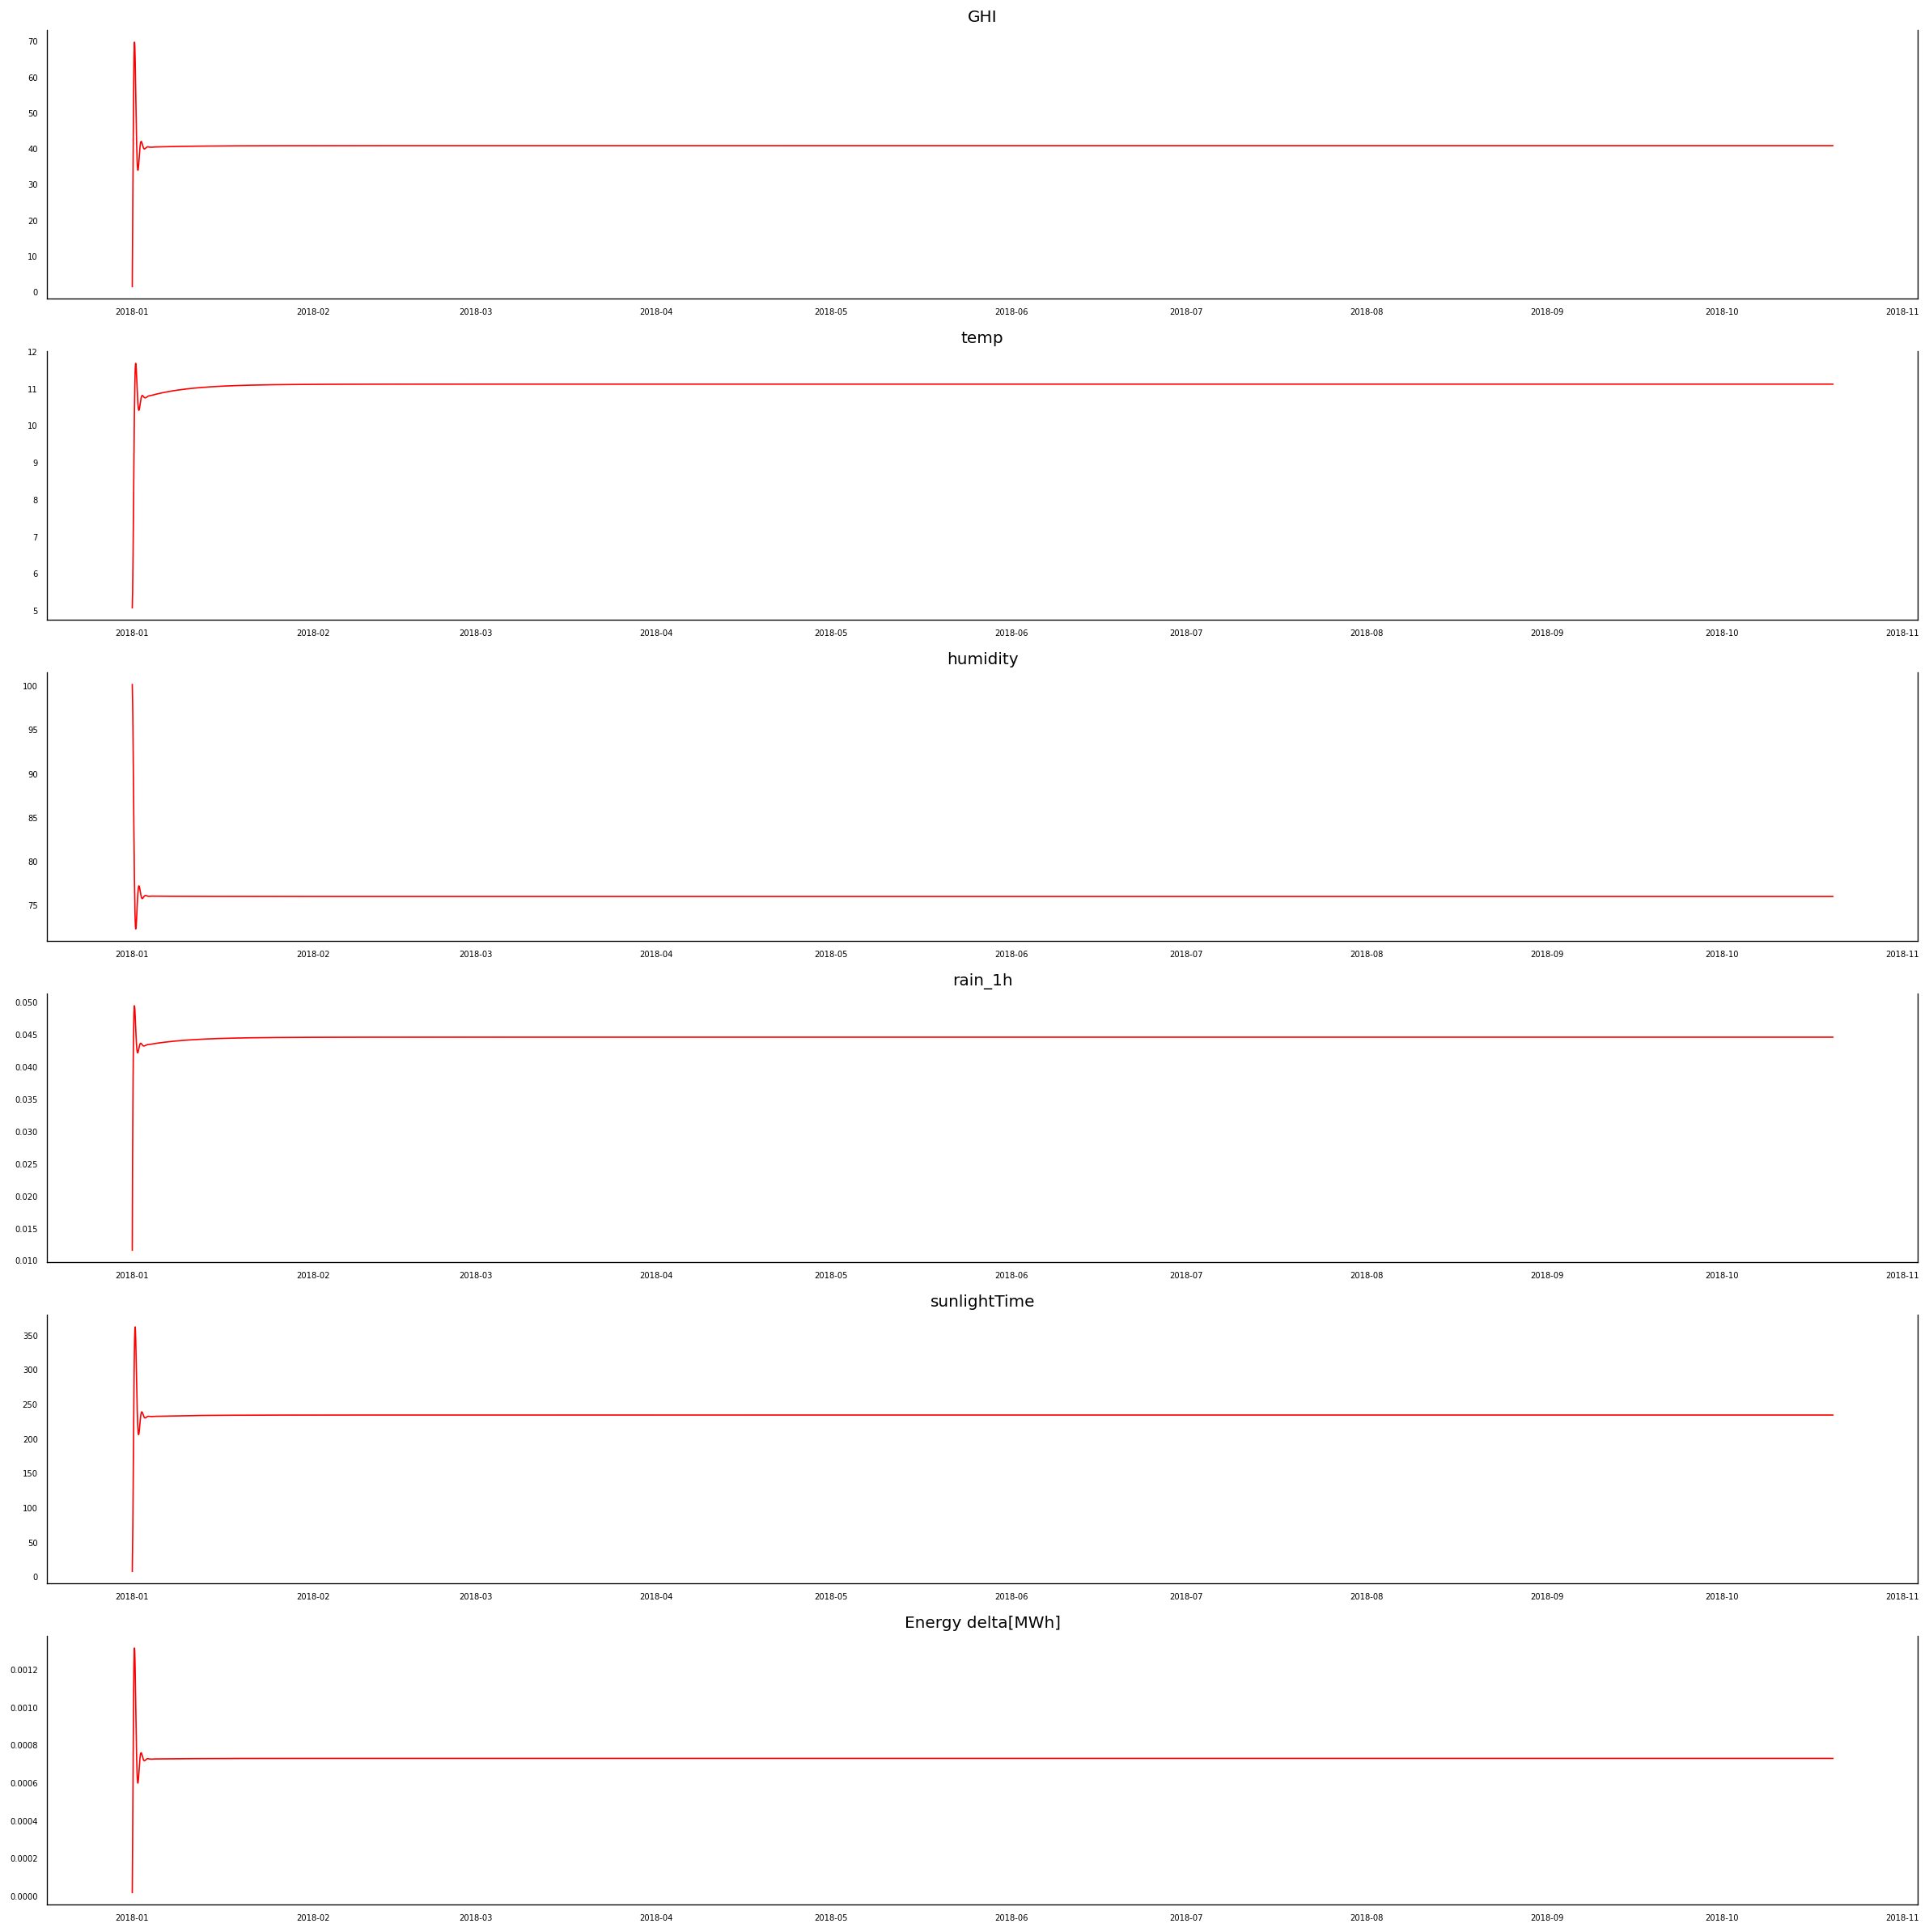

In [75]:
fig, axes = plt.subplots(nrows=len(X_V.columns), ncols=1, dpi=120, figsize=(20,20))
for i, ax in enumerate(axes.flatten()):
    data = forecast[forecast.columns[i]]
    ax.plot(data, color='red', linewidth=1)
    # Decorations
    ax.set_title(forecast.columns[i])
    ax.xaxis.set_ticks_position('none')
    ax.yaxis.set_ticks_position('none')
    ax.spines["top"].set_alpha(0)
    ax.tick_params(labelsize=6)

plt.tight_layout();

# NOW CREATE A DATASET FOR ENSEMBLE ***MODEL***

In [76]:
start=0
end=len(Y_train_A)-1

#if the predicted values dont have date values as index, you will have to uncomment the following two commented lines to plot a graph

PredA = modelA.predict(start=start, end=end, typ='levels').rename('SARIMAX predictions')

index_future_dates = pd.date_range(start='2018-01-01', periods=len(PredA), freq='15T')
PredA.index = index_future_dates[:len(PredA)]
PredA=PredA.to_frame()
PredA.columns=['Energy delta[MWh]']




In [77]:
PredA

,Energy delta[MWh]
2018-01-01 00:00:00,0.000000e+00
2018-01-01 00:15:00,0.000000e+00
2018-01-01 00:30:00,0.000000e+00
2018-01-01 00:45:00,0.000000e+00
2018-01-01 01:00:00,0.000000e+00
...,...
2018-10-19 22:45:00,-1.943805e-07
2018-10-19 23:00:00,1.920153e-07
2018-10-19 23:15:00,-1.796048e-07
2018-10-19 23:30:00,-1.015194e-08


In [78]:
yPred=modelL.predict(X_train_L)
yPred

875/875 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step


array([[ 9.8869205e-05,  4.3459293e-01,  6.2913966e-01,  5.8877990e-03,
         2.1244586e-03,  1.3569891e-02],
       [ 8.8135898e-04,  4.2480338e-01,  6.4357662e-01,  2.4259351e-03,
        -1.2235463e-02,  2.2244200e-02],
       [ 6.5322071e-03,  4.2290729e-01,  6.4558679e-01,  4.3441653e-03,
        -4.4089556e-04,  1.9768938e-02],
       ...,
       [ 4.1252971e-03,  3.7319079e-01,  9.6198583e-01,  7.4515138e-03,
        -3.3015013e-04,  1.6294599e-02],
       [ 4.9784631e-03,  3.7226486e-01,  9.6347731e-01,  7.4167941e-03,
         4.6870112e-04,  1.7201379e-02],
       [ 4.3861419e-03,  3.7149361e-01,  9.6526164e-01,  7.3374873e-03,
         3.6859512e-04,  1.6716167e-02]], dtype=float32)

In [79]:
yPred.shape

(27984, 6)

In [80]:
X_L.shape

(35040, 6)

In [81]:
PredL=pd.DataFrame(yPred)
PredL.columns=X_L.columns
PredL.index=X_L.index[:len(yPred)]


In [82]:
PredL

,GHI,temp,humidity,rain_1h,sunlightTime,Energy delta[MWh]
Time,,,,,,
2018-01-01 00:00:00,0.000099,0.434593,0.629140,0.005888,0.002124,0.013570
2018-01-01 00:15:00,0.000881,0.424803,0.643577,0.002426,-0.012235,0.022244
2018-01-01 00:30:00,0.006532,0.422907,0.645587,0.004344,-0.000441,0.019769
2018-01-01 00:45:00,0.008099,0.421949,0.646632,0.004206,0.002963,0.018752
2018-01-01 01:00:00,0.008712,0.423222,0.643555,0.004581,0.000958,0.018062
...,...,...,...,...,...,...
2018-10-19 10:45:00,0.005275,0.374644,0.962601,0.006889,0.002469,0.016773
2018-10-19 11:00:00,0.006731,0.376202,0.960077,0.007298,0.001534,0.018137
2018-10-19 11:15:00,0.004125,0.373191,0.961986,0.007452,-0.000330,0.016295


In [83]:
PredV=pd.DataFrame(forecast)
PredV.columns=X_V.columns
PredV.index=X_V.index[-len(forecast):]
PredV

,GHI,temp,humidity,rain_1h,sunlightTime,Energy delta[MWh]
Time,,,,,,
2018-03-15 00:00:00,1.557553,5.086587,100.191125,0.011654,8.285607,0.000020
2018-03-15 00:15:00,3.905273,5.147998,99.881508,0.015633,14.693610,0.000057
2018-03-15 00:30:00,6.257763,5.213472,99.569535,0.019409,20.942437,0.000101
2018-03-15 00:45:00,8.707122,5.282417,99.254822,0.022515,27.667589,0.000148
2018-03-15 01:00:00,11.337879,5.289231,99.173043,0.023642,33.729124,0.000198
...,...,...,...,...,...,...
2018-12-31 22:45:00,40.933701,11.128025,76.036561,0.044611,234.710020,0.000731
2018-12-31 23:00:00,40.933701,11.128025,76.036561,0.044611,234.710020,0.000731
2018-12-31 23:15:00,40.933701,11.128025,76.036561,0.044611,234.710020,0.000731


In [84]:
PredL['Energy delta[MWh]']

,Energy delta[MWh]
Time,
2018-01-01 00:00:00,0.013570
2018-01-01 00:15:00,0.022244
2018-01-01 00:30:00,0.019769
2018-01-01 00:45:00,0.018752
2018-01-01 01:00:00,0.018062
...,...
2018-10-19 10:45:00,0.016773
2018-10-19 11:00:00,0.018137
2018-10-19 11:15:00,0.016295


In [85]:
Y=Y.to_frame()
Y


,Energy delta[MWh]
Time,
2018-01-01 00:00:00,0.0
2018-01-01 00:15:00,0.0
2018-01-01 00:30:00,0.0
2018-01-01 00:45:00,0.0
2018-01-01 01:00:00,0.0
...,...
2018-12-31 22:45:00,0.0
2018-12-31 23:00:00,0.0
2018-12-31 23:15:00,0.0


In [86]:
# Step 1: Convert all variables into DataFrames with column names
y_train_A = pd.DataFrame(PredA['Energy delta[MWh]'])
y_train_L = pd.DataFrame(PredL['Energy delta[MWh]'])
y_train_V = pd.DataFrame(PredV['Energy delta[MWh]'])
y_train_R = pd.DataFrame(Y['Energy delta[MWh]'])

# Step 2: Concatenate the DataFrames along columns
y_train_combined = pd.concat([y_train_A, y_train_L, y_train_V, y_train_R], axis=1)
y_train_combined.columns = ['ARIMA', 'LSTM', 'VAM', 'Actual Value']


In [87]:
y_train_combined.dropna(inplace=True)

In [88]:
y_train_combined

,ARIMA,LSTM,VAM,Actual Value
2018-03-15 00:00:00,1.379703e-08,0.337828,0.000020,0.000000
2018-03-15 00:15:00,8.868968e-09,0.299900,0.000057,0.000000
2018-03-15 00:30:00,4.207218e-09,0.230655,0.000101,0.000000
2018-03-15 00:45:00,-7.896906e-09,0.148020,0.000148,0.000000
2018-03-15 01:00:00,6.465256e-10,0.075136,0.000198,0.000000
...,...,...,...,...
2018-10-19 10:45:00,-5.009134e-05,0.016773,0.000731,0.001664
2018-10-19 11:00:00,-1.389784e-04,0.018137,0.000731,0.001448
2018-10-19 11:15:00,-2.162851e-05,0.016295,0.000731,0.001218
2018-10-19 11:30:00,1.695299e-04,0.017201,0.000731,0.001256


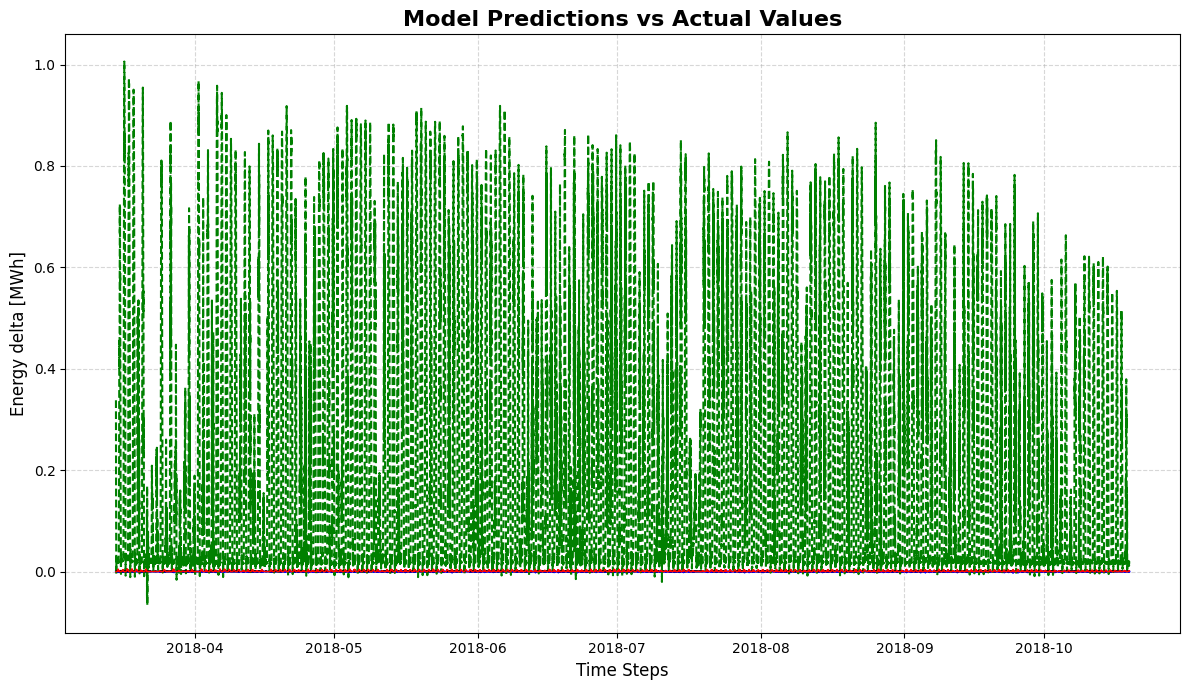

In [89]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 7))

plt.plot(y_train_combined['ARIMA'], color='blue', linestyle='-', label='ARIMA')
plt.plot(y_train_combined['LSTM'], color='green', linestyle='--', label='LSTM')
plt.plot(y_train_combined['VAM'], color='black', linestyle='-.', label='VAM')
plt.plot(y_train_combined['Actual Value'], color='red', linestyle='-', linewidth=1, label='Actual Value')
plt.title("Model Predictions vs Actual Values", fontsize=16, fontweight='bold')
plt.xlabel("Time Steps", fontsize=12)
plt.ylabel("Energy delta [MWh]", fontsize=12)

# Add grid lines
plt.grid(True, linestyle='--', alpha=0.5)

# Show the plot
plt.tight_layout()  # Adjust layout for better spacing
plt.show()



# ***NOW BEGIN WITH  ENSEMBLE MODEL***

In [90]:
X_train, X_test, y_train, y_test = train_test_split(y_train_combined.drop('Actual Value',axis=1),y_train_combined['Actual Value'], test_size = 0.2, random_state=42,shuffle=False)
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((16780, 3), (16780,), (4196, 3), (4196,))

In [91]:
X_test

,ARIMA,LSTM,VAM
2018-09-05 19:00:00,0.000051,0.304723,0.000731
2018-09-05 19:15:00,0.000003,0.359900,0.000731
2018-09-05 19:30:00,-0.000022,0.590154,0.000731
2018-09-05 19:45:00,0.000012,0.407277,0.000731
2018-09-05 20:00:00,0.000023,0.731871,0.000731
...,...,...,...
2018-10-19 10:45:00,-0.000050,0.016773,0.000731
2018-10-19 11:00:00,-0.000139,0.018137,0.000731
2018-10-19 11:15:00,-0.000022,0.016295,0.000731
2018-10-19 11:30:00,0.000170,0.017201,0.000731


# ***MLP***

In [92]:
import tensorflow as tf

from tensorflow.keras import Sequential
from tensorflow.keras.layers import LSTM, Dropout, Dense

In [93]:
model_mlp=Sequential([
    Dense(100,input_shape=(3,),activation='relu'),
    Dense(100,activation='relu'),
    Dense(1,activation='linear'),
])

In [94]:
model_mlp.compile(loss='mse',optimizer='adam',metrics=['mae'])

In [95]:
model_mlp.fit(X_train,y_train,epochs=20,batch_size=1,verbose=1)

Epoch 1/20
16780/16780 ━━━━━━━━━━━━━━━━━━━━ 25s 1ms/step - loss: 9.8744e-06 - mae: 0.0015
Epoch 2/20
16780/16780 ━━━━━━━━━━━━━━━━━━━━ 41s 1ms/step - loss: 1.8750e-06 - mae: 0.0011
Epoch 3/20
16780/16780 ━━━━━━━━━━━━━━━━━━━━ 23s 1ms/step - loss: 1.8250e-06 - mae: 0.0011
Epoch 4/20
16780/16780 ━━━━━━━━━━━━━━━━━━━━ 41s 1ms/step - loss: 1.8313e-06 - mae: 0.0011
Epoch 5/20
16780/16780 ━━━━━━━━━━━━━━━━━━━━ 24s 1ms/step - loss: 1.7331e-06 - mae: 0.0010
Epoch 6/20
16780/16780 ━━━━━━━━━━━━━━━━━━━━ 23s 1ms/step - loss: 1.7242e-06 - mae: 0.0010
Epoch 7/20
16780/16780 ━━━━━━━━━━━━━━━━━━━━ 24s 1ms/step - loss: 1.7056e-06 - mae: 0.0010
Epoch 8/20
16780/16780 ━━━━━━━━━━━━━━━━━━━━ 23s 1ms/step - loss: 1.7086e-06 - mae: 0.0010
Epoch 9/20
16780/16780 ━━━━━━━━━━━━━━━━━━━━ 23s 1ms/step - loss: 1.7149e-06 - mae: 0.0010
Epoch 10/20
16780/16780 ━━━━━━━━━━━━━━━━━━━━ 23s 1ms/step - loss: 1.6995e-06 - mae: 0.0010
Epoch 11/20
16780/16780 ━━━━━━━━━━━━━━━━━━━━ 23s 1ms/step - loss: 1.6719e-06 - mae: 0.0010
Epoch 12

In [96]:
model_mlp.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                      │ (None, 100)                 │             400 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 100)                 │          10,100 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │             101 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 31,805 (124.24 KB)

 Trainable params: 10,601 (41.41 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 21,204 (82.83 KB)

In [97]:
model_mlp_res=model_mlp.predict(X_test)

132/132 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [98]:
MLPdf = pd.DataFrame(model_mlp_res, columns=["MLP Output"])

In [99]:
MLPdf.index=X_test.index
MLPdf

,MLP Output
2018-09-05 19:00:00,0.000761
2018-09-05 19:15:00,0.000668
2018-09-05 19:30:00,0.000655
2018-09-05 19:45:00,0.000665
2018-09-05 20:00:00,0.000647
...,...
2018-10-19 10:45:00,0.001964
2018-10-19 11:00:00,0.001964
2018-10-19 11:15:00,0.001964
2018-10-19 11:30:00,0.001964


# ***CNN MODEL***

In [100]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense
from tensorflow.keras.optimizers import Adam

In [101]:
model_cnn=Sequential([
    Conv1D(128,kernel_size=2,input_shape=(3,1),activation='relu'),
    MaxPooling1D(pool_size=2),
    Dense(64,activation='relu'),
    Dense(1,activation='linear'),
])


In [102]:
model_cnn.compile(loss='mse',optimizer='adam',metrics=['mae'])

In [103]:
# Summary of the model
model_cnn.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                      │ (None, 2, 128)              │             384 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d (MaxPooling1D)         │ (None, 1, 128)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 1, 64)               │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 1, 1)                │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 8,705 (34.00 KB)

 Trainable params: 8,705 (34.00 KB)

 Non-trainable params: 0 (0.00 B)

In [104]:
history = model_cnn.fit(X_train,y_train,epochs=20,batch_size=1,verbose=1)

Epoch 1/20
16780/16780 ━━━━━━━━━━━━━━━━━━━━ 24s 1ms/step - loss: 9.4085e-06 - mae: 0.0016
Epoch 2/20
16780/16780 ━━━━━━━━━━━━━━━━━━━━ 41s 1ms/step - loss: 1.8595e-06 - mae: 0.0011
Epoch 3/20
16780/16780 ━━━━━━━━━━━━━━━━━━━━ 24s 1ms/step - loss: 1.8087e-06 - mae: 0.0011
Epoch 4/20
16780/16780 ━━━━━━━━━━━━━━━━━━━━ 25s 1ms/step - loss: 1.8168e-06 - mae: 0.0011
Epoch 5/20
16780/16780 ━━━━━━━━━━━━━━━━━━━━ 41s 1ms/step - loss: 1.8041e-06 - mae: 0.0011
Epoch 6/20
16780/16780 ━━━━━━━━━━━━━━━━━━━━ 24s 1ms/step - loss: 1.8059e-06 - mae: 0.0011
Epoch 7/20
16780/16780 ━━━━━━━━━━━━━━━━━━━━ 25s 1ms/step - loss: 1.8189e-06 - mae: 0.0011
Epoch 8/20
16780/16780 ━━━━━━━━━━━━━━━━━━━━ 23s 1ms/step - loss: 1.7881e-06 - mae: 0.0011
Epoch 9/20
16780/16780 ━━━━━━━━━━━━━━━━━━━━ 24s 1ms/step - loss: 1.8245e-06 - mae: 0.0011
Epoch 10/20
16780/16780 ━━━━━━━━━━━━━━━━━━━━ 25s 1ms/step - loss: 1.7827e-06 - mae: 0.0011
Epoch 11/20
16780/16780 ━━━━━━━━━━━━━━━━━━━━ 41s 1ms/step - loss: 1.8275e-06 - mae: 0.0011
Epoch 12

In [105]:
model_cnn_res=model_cnn.predict(X_test)


132/132 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [106]:
model_cnn_ = model_cnn_res.reshape(-1, 1)
CNNdf = pd.DataFrame(model_cnn_, columns=["CNN Output"])


In [107]:
CNNdf.index=X_test.index
CNNdf

,CNN Output
2018-09-05 19:00:00,-0.000455
2018-09-05 19:15:00,-0.000455
2018-09-05 19:30:00,-0.000455
2018-09-05 19:45:00,-0.000455
2018-09-05 20:00:00,-0.000455
...,...
2018-10-19 10:45:00,0.000766
2018-10-19 11:00:00,0.000762
2018-10-19 11:15:00,0.000766
2018-10-19 11:30:00,0.000766


# ***SIMPLE MEAN***

In [108]:
X_test['Simple Mean'] = X_test.mean(axis=1)


In [109]:
SimpleMean=X_test['Simple Mean']
SimpleMean

,Simple Mean
2018-09-05 19:00:00,0.101835
2018-09-05 19:15:00,0.120211
2018-09-05 19:30:00,0.196954
2018-09-05 19:45:00,0.136007
2018-09-05 20:00:00,0.244208
...,...
2018-10-19 10:45:00,0.005818
2018-10-19 11:00:00,0.006243
2018-10-19 11:15:00,0.005668
2018-10-19 11:30:00,0.006034


In [110]:
ActualData=y_test
ActualData=pd.DataFrame(ActualData)
ActualData.index=X_test.index
ActualData.columns=['Actual Value']
ActualData

,Actual Value
2018-09-05 19:00:00,0.000000
2018-09-05 19:15:00,0.000000
2018-09-05 19:30:00,0.000000
2018-09-05 19:45:00,0.000000
2018-09-05 20:00:00,0.000000
...,...
2018-10-19 10:45:00,0.001664
2018-10-19 11:00:00,0.001448
2018-10-19 11:15:00,0.001218
2018-10-19 11:30:00,0.001256


In [111]:
FinalDataframe=pd.concat([SimpleMean,MLPdf,CNNdf,ActualData],axis=1)
FinalDataframe

,Simple Mean,MLP Output,CNN Output,Actual Value
2018-09-05 19:00:00,0.101835,0.000761,-0.000455,0.000000
2018-09-05 19:15:00,0.120211,0.000668,-0.000455,0.000000
2018-09-05 19:30:00,0.196954,0.000655,-0.000455,0.000000
2018-09-05 19:45:00,0.136007,0.000665,-0.000455,0.000000
2018-09-05 20:00:00,0.244208,0.000647,-0.000455,0.000000
...,...,...,...,...
2018-10-19 10:45:00,0.005818,0.001964,0.000766,0.001664
2018-10-19 11:00:00,0.006243,0.001964,0.000762,0.001448
2018-10-19 11:15:00,0.005668,0.001964,0.000766,0.001218
2018-10-19 11:30:00,0.006034,0.001964,0.000766,0.001256


In [112]:
model_cnn_tra=model_cnn.predict(X_train)
model_cnn_tra = model_cnn_tra.reshape(-1, 1)
CNNdf_tra = pd.DataFrame(model_cnn_tra, columns=["CNN Output"])
CNNdf_tra.index=X_train.index
CNNdf_tra

525/525 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


,CNN Output
2018-03-15 00:00:00,-0.000455
2018-03-15 00:15:00,-0.000455
2018-03-15 00:30:00,-0.000455
2018-03-15 00:45:00,-0.000047
2018-03-15 01:00:00,0.000407
...,...
2018-09-05 17:45:00,-0.000455
2018-09-05 18:00:00,-0.000455
2018-09-05 18:15:00,-0.000455
2018-09-05 18:30:00,-0.000455


In [113]:
model_mlp_tra=model_mlp.predict(X_train)
MLPdf_tra = pd.DataFrame(model_mlp_tra, columns=["MLP Output"])
MLPdf_tra.index=X_train.index
MLPdf_tra

525/525 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


,MLP Output
2018-03-15 00:00:00,0.000692
2018-03-15 00:15:00,0.000772
2018-03-15 00:30:00,0.000918
2018-03-15 00:45:00,0.001093
2018-03-15 01:00:00,0.001247
...,...
2018-09-05 17:45:00,0.000711
2018-09-05 18:00:00,0.000662
2018-09-05 18:15:00,0.000662
2018-09-05 18:30:00,0.000662


In [114]:
simple_mean_tra=X_train.mean(axis=1)
simple_mean_tra

,0
2018-03-15 00:00:00,0.112616
2018-03-15 00:15:00,0.099986
2018-03-15 00:30:00,0.076919
2018-03-15 00:45:00,0.049389
2018-03-15 01:00:00,0.025111
...,...
2018-09-05 17:45:00,0.109806
2018-09-05 18:00:00,0.150122
2018-09-05 18:15:00,0.153820
2018-09-05 18:30:00,0.154230


In [115]:
simple_mean_tra=pd.DataFrame(simple_mean_tra,columns=['Simple Mean'])
simple_mean_tra.index=X_train.index
simple_mean_tra

,Simple Mean
2018-03-15 00:00:00,0.112616
2018-03-15 00:15:00,0.099986
2018-03-15 00:30:00,0.076919
2018-03-15 00:45:00,0.049389
2018-03-15 01:00:00,0.025111
...,...
2018-09-05 17:45:00,0.109806
2018-09-05 18:00:00,0.150122
2018-09-05 18:15:00,0.153820
2018-09-05 18:30:00,0.154230


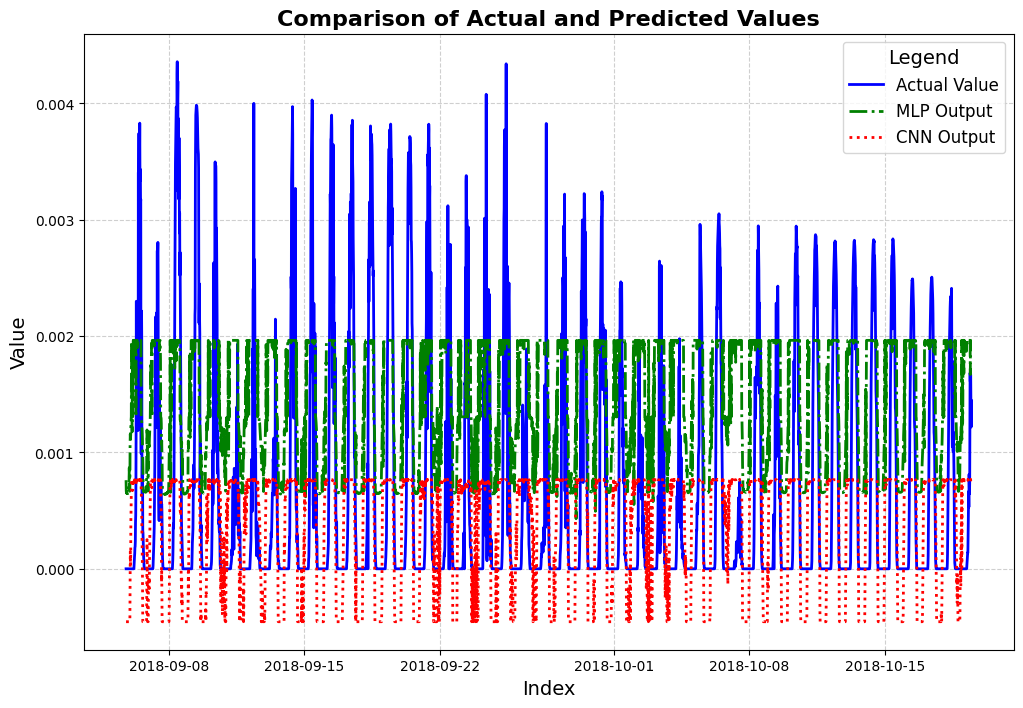

In [116]:
import matplotlib.pyplot as plt

# Set the figure size
plt.figure(figsize=(12, 8))

# Plot each line with custom styles
plt.plot(FinalDataframe['Actual Value'], label='Actual Value', color='blue', linestyle='-', linewidth=2)
# plt.plot(FinalDataframe['Simple Mean'], label='Simple Mean', color='orange', linestyle='--', linewidth=2)
plt.plot(FinalDataframe['MLP Output'], label='MLP Output', color='green', linestyle='-.', linewidth=2)
plt.plot(FinalDataframe['CNN Output'], label='CNN Output', color='red', linestyle=':', linewidth=2)

# Add title and labels
plt.title('Comparison of Actual and Predicted Values', fontsize=16, fontweight='bold')
plt.xlabel('Index', fontsize=14)
plt.ylabel('Value', fontsize=14)

# Customize legend
plt.legend(loc='best', fontsize=12, title='Legend', title_fontsize=14)

# Add grid for better readability
plt.grid(True, linestyle='--', alpha=0.6)

# Show the plot
plt.show()


In [117]:
ensemble_model_train=pd.concat([simple_mean_tra,MLPdf_tra,CNNdf_tra,y_train],axis=1)
ensemble_model_train

,Simple Mean,MLP Output,CNN Output,Actual Value
2018-03-15 00:00:00,0.112616,0.000692,-0.000455,0.0
2018-03-15 00:15:00,0.099986,0.000772,-0.000455,0.0
2018-03-15 00:30:00,0.076919,0.000918,-0.000455,0.0
2018-03-15 00:45:00,0.049389,0.001093,-0.000047,0.0
2018-03-15 01:00:00,0.025111,0.001247,0.000407,0.0
...,...,...,...,...
2018-09-05 17:45:00,0.109806,0.000711,-0.000455,0.0
2018-09-05 18:00:00,0.150122,0.000662,-0.000455,0.0
2018-09-05 18:15:00,0.153820,0.000662,-0.000455,0.0
2018-09-05 18:30:00,0.154230,0.000662,-0.000455,0.0


In [118]:
y_train_combined

,ARIMA,LSTM,VAM,Actual Value
2018-03-15 00:00:00,1.379703e-08,0.337828,0.000020,0.000000
2018-03-15 00:15:00,8.868968e-09,0.299900,0.000057,0.000000
2018-03-15 00:30:00,4.207218e-09,0.230655,0.000101,0.000000
2018-03-15 00:45:00,-7.896906e-09,0.148020,0.000148,0.000000
2018-03-15 01:00:00,6.465256e-10,0.075136,0.000198,0.000000
...,...,...,...,...
2018-10-19 10:45:00,-5.009134e-05,0.016773,0.000731,0.001664
2018-10-19 11:00:00,-1.389784e-04,0.018137,0.000731,0.001448
2018-10-19 11:15:00,-2.162851e-05,0.016295,0.000731,0.001218
2018-10-19 11:30:00,1.695299e-04,0.017201,0.000731,0.001256


In [119]:
monthly_data_combined = y_train_combined.resample('M').mean()


In [120]:
monthly_data_combined

,ARIMA,LSTM,VAM,Actual Value
2018-03-31,-9.954014e-12,0.142651,0.000736,0.000647
2018-04-30,1.523777e-10,0.208719,0.000731,0.000925
2018-05-31,-1.343398e-10,0.249184,0.000731,0.001109
2018-06-30,-5.111024e-11,0.210700,0.000731,0.000941
2018-07-31,-2.700154e-11,0.197994,0.000731,0.000867
2018-08-31,1.615659e-10,0.199859,0.000731,0.000902
2018-09-30,-9.803955e-11,0.157030,0.000731,0.000717
2018-10-31,5.484779e-08,0.125313,0.000731,0.000548


In [121]:
monthly_data_ensemble = ensemble_model_train.resample('M').mean()
monthly_data_ensemble

,Simple Mean,MLP Output,CNN Output,Actual Value
2018-03-31,0.047796,0.001471,0.000405,0.000647
2018-04-30,0.069817,0.001352,0.000274,0.000925
2018-05-31,0.083305,0.001265,0.000206,0.001109
2018-06-30,0.070477,0.001257,0.000199,0.000941
2018-07-31,0.066242,0.001271,0.000214,0.000867
2018-08-31,0.066863,0.001327,0.000253,0.000902
2018-09-30,0.056645,0.001402,0.000304,0.000909


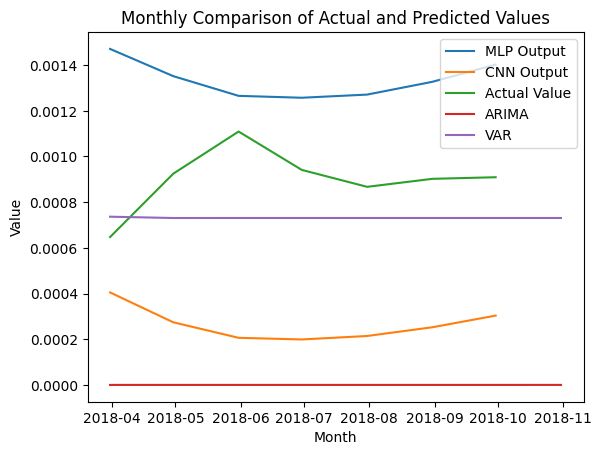

In [124]:
# plt.plot(monthly_data_ensemble.index, monthly_data_ensemble['Simple Mean'], label='Simple Mean')
plt.plot(monthly_data_ensemble.index, monthly_data_ensemble['MLP Output'], label='MLP Output')
plt.plot(monthly_data_ensemble.index, monthly_data_ensemble['CNN Output'], label='CNN Output')
plt.plot(monthly_data_ensemble.index, monthly_data_ensemble['Actual Value'], label='Actual Value')
plt.plot(monthly_data_combined.index, monthly_data_combined['ARIMA'], label='ARIMA')
# plt.plot(monthly_data_combined.index, monthly_data_combined['LSTM'], label='LSTM')
plt.plot(monthly_data_combined.index, monthly_data_combined['VAM'], label='VAR')
plt.title('Monthly Comparison of Actual and Predicted Values')
plt.xlabel('Month')
plt.ylabel('Value')
plt.legend()
plt.show()

***PREDICTED OUTPUT FROM RESEARCH PAPER***

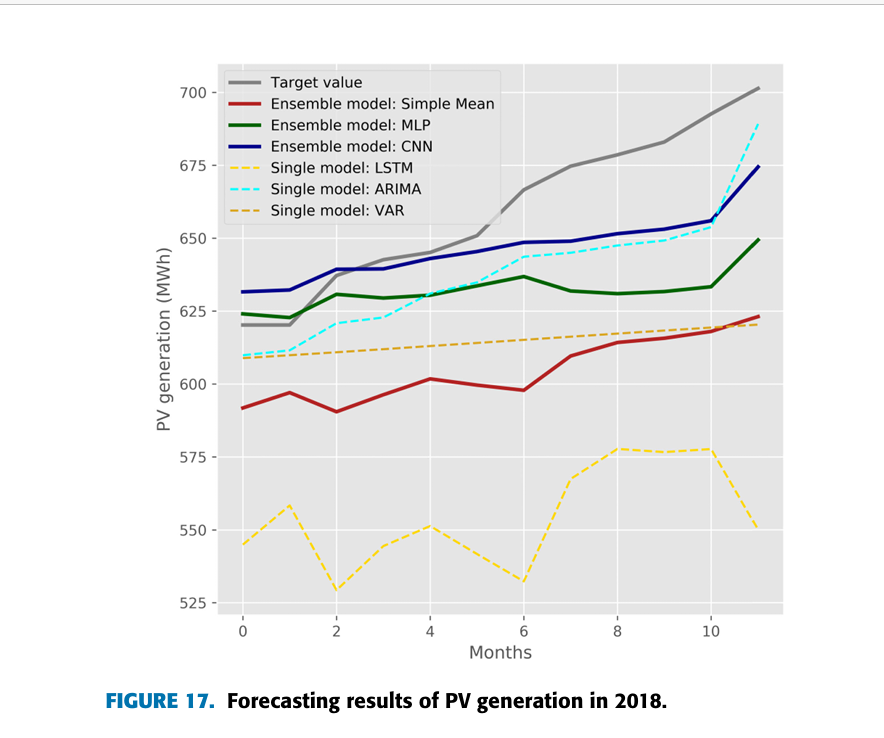